# Closed Lost Deal Analysis

Analysis of closed-lost deals from the Classic pipeline using:
- `PORT_ANALYTICS_PROD.DWH.FACT_DEALS` — deal facts
- `PORT_ANALYTICS_PROD.DWH.DIM_COMPANY` — company segment
- `PORT_ANALYTICS_PROD.DWH.DIM_EMPLOYEE` — sales owner info
- `RAW_PORT_EXTERNAL.AB_HUBSPOT_HISTORY.DEALS_PROPERTY_HISTORY` — property change history

## Global Filters & Parameters

Applied to every chart unless explicitly overridden.

In [54]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import snowflake.connector

conn = snowflake.connector.connect(
    connection_name=os.getenv("SNOWFLAKE_CONNECTION_NAME", "default")
)
print(f"Connected as {conn.user} / role={conn.role}")

def run_query(sql):
    """Execute SQL and return a pandas DataFrame."""
    cur = conn.cursor()
    cur.execute(sql)
    df = cur.fetch_pandas_all()
    cur.close()
    return df

# Hard-coded close date fix: these 6 Rick Walker deals were bulk-closed at
# 2026-03-31 22:09-22:13 UTC but the correct close date is 2026-04-01 (per HubSpot CSV).
DEAL_CLOSED_DATE_OVERRIDE = """
    CASE WHEN d.DEAL_CRM_ID IN (33297358370, 29895061171, 31604102818,
                                 43823947376, 39054444808, 22619273319)
         THEN '2026-04-01'::DATE
         ELSE d.DEAL_CLOSED_DATE
    END
""".strip()

# Trailing quarters to include (adjustable)
N_QUARTERS = 8

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://sso.jumpcloud.com/saml2/psf?SAMLRequest=nZJBT%2BMwEIX%2FSuQ9N04CRV2rLQoNdAOFVk1AgsvKTdzWrWMHj0MKv36dpJXYAxy4Rc57883Mm%2BHloRDOG9PAlRwh3%2FWQw2Smci43I%2FSY3vQGyAFDZU6FkmyE3hmgy%2FEQaCFKElZmK5fstWJgHFtIAml%2BjFClJVEUOBBJCwbEZCQJ72ckcD1CAZg2FoeOlhy4ZW2NKQnGdV279Zmr9AYHnudh7ze2qkbyC31ClN8zSq2MypQ4WQ52pi8QPvbOG4RVWMLiaLzislvBd5RVJwLyJ00XvcU8SZETnqabKAlVwXTC9BvP2ONy1jUAtoPF7dPVPLm2lmX6N3wIZ89pPElckKpeC7pnmSrKytjSrv3Ca5ZjoTbcLiyORqjc87x%2Ft9qX8EE32TPdXQyiw57uVh9TOp0nd9exTItptH3NotnudpMh5%2BkUb9DEGwNULJZNqMY%2BecFFzxv0vLPUPyeBT%2Fy%2B2w%2BCF%2BRENlQuqWmdp84BlLurijITqsrb7po0AlzCGnVXQdr6evyjWYf4c4njlT3YxcfRQgmevTs3ShfUfJ2L7%2FrtC89761ZKWEG5CPNcMwCbjxCqnmhGjT1moyuG8Lij%2Fn%2FO438%3D&RelayState=ver%3A3-hint%3A5187783633989638-ETMsDgAAAZ%2FIABGCABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPaHx3beSwRSshLAmUT6RoQAAACg6IsOSvSl9hTQEVLHECfDx%2Ftrqw5w37rVRNrviXmDFPn1Fd0fplCPDxf7r3rBq4sdJ%2B7tV4s%2F

 pip install snowflake-connector-python[secure-local-storage]


## HubSpot Data (CSV)

Load the main lost deals export + property history CSVs for stage-before-closed and deal-owner.

In [55]:
from pathlib import Path
import csv

# =============================================================================
# EXTRACT: Load HubSpot main lost deals export (flat, one row per deal)
# =============================================================================
MAIN_CSV = 'hubspot-crm-exports-main-lost-list-2024-2026-2026-07-06.csv'
hs_deals = pd.read_csv(MAIN_CSV, dtype={'Record ID': str})

# =============================================================================
# TRANSFORM: Clean and normalize
# =============================================================================
hs_deals = hs_deals.rename(columns=lambda c: c.strip())
hs_deals['Record ID'] = hs_deals['Record ID'].astype(str).str.strip()

# Parse dates
for col in ['Close Date', 'Create Date', 'Qualified Date']:
    hs_deals[col] = pd.to_datetime(hs_deals[col], format='mixed', errors='coerce')

# Parse numeric
hs_deals['Amount'] = pd.to_numeric(hs_deals['Amount'], errors='coerce')
hs_deals['Previous Amount'] = pd.to_numeric(hs_deals['Previous Amount'], errors='coerce')

# Clean text fields
for col in ['Evaluated competitors', 'Deal Stage Before Closed', 'Closed Lost Reason', 'Segment', 'Deal owner']:
    if col in hs_deals.columns:
        hs_deals[col] = hs_deals[col].astype(str).str.strip().replace({'nan': None, '': None})

# Add quarter column
hs_deals['close_quarter'] = hs_deals['Close Date'].dt.year.astype(str) + '-Q' + hs_deals['Close Date'].dt.quarter.astype(str)

# Filter to close date <= 2026-06-30
hs_deals = hs_deals[hs_deals['Close Date'] <= '2026-06-30'].reset_index(drop=True)

# Unified segment logic: team name overrides, then CSV Segment (from DIM_COMPANY)
def assign_segment(row):
    team = str(row.get('HubSpot Team', '') or '').lower()
    if 'ent' in team:
        return 'Enterprise'
    if 'mm' in team:
        return 'Mid-Market'
    # Fall back to Segment column from CSV (sourced from DIM_COMPANY)
    seg = row.get('Segment')
    if pd.notna(seg) and str(seg).strip():
        return str(seg).strip()
    return 'Unknown'

hs_deals['segment'] = hs_deals.apply(assign_segment, axis=1)

print(f"Loaded {len(hs_deals)} lost deals from HubSpot CSV (filtered <= 2026-06-30)")
print(f"Date range: {hs_deals['Close Date'].min():%Y-%m-%d} → {hs_deals['Close Date'].max():%Y-%m-%d}")
print(f"Segment distribution:\n{hs_deals['segment'].value_counts()}")

# =============================================================================
# EXTRACT + TRANSFORM: Property history CSVs (for owner changes)
# =============================================================================
HISTORY_FILES = {
    'stage_before_closed': 'hubspot-crm-exports-deal-stage-before-closed-2026-07-06.csv',
    'deal_owner': 'hubspot-crm-exports-deal-owner-2026-07-06.csv',
}

def extract_hubspot_history_csv(filepath):
    """Read ragged HubSpot property history CSV using csv.reader."""
    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        all_rows = list(reader)
    max_cols = max(len(header), max((len(r) for r in all_rows), default=0))
    padded = [row + [None] * (max_cols - len(row)) for row in all_rows]
    col_names = header + [f'_overflow_{i}' for i in range(max_cols - len(header))]
    return pd.DataFrame(padded, columns=col_names)

def unpivot_history(raw_df):
    """Unpivot wide-format history into long format [deal_id, value, timestamp]."""
    cols = raw_df.columns.tolist()
    named_cols = [c for c in cols if not str(c).startswith('_overflow_')]
    overflow_cols = sorted([c for c in cols if str(c).startswith('_overflow_')], key=lambda x: int(x.split('_')[-1]))
    
    # Find current value + date columns (handle timezone suffix like "(Asia/Jerusalem)")
    current_val_col = next(c for c in named_cols if 'Current Value' in c)
    current_date_col = next(c for c in named_cols if 'Change Date' in c and not any(f'({i})' in c for i in range(1, 100)))
    
    # Find max named slot
    max_slot = max((int(c.split('(')[1].split(')')[0]) for c in named_cols if 'Previous Value (' in c), default=0)
    
    records = []
    for _, row in raw_df.iterrows():
        deal_id = str(row.get('Record ID', '')).strip()
        if not deal_id:
            continue
        
        # Current value
        val, dt = row.get(current_val_col), row.get(current_date_col)
        if pd.notna(val) and pd.notna(dt) and str(val).strip():
            records.append({'deal_id': deal_id, 'value': str(val).strip(), 'timestamp': str(dt).strip()})
        
        # Named slots
        for i in range(1, max_slot + 1):
            val_col = f'Previous Value ({i})'
            date_cands = [c for c in named_cols if f'Change Date ({i})' in c]
            if val_col not in cols or not date_cands:
                break
            val, dt = row.get(val_col), row.get(date_cands[0])
            if pd.notna(val) and pd.notna(dt) and str(val).strip():
                records.append({'deal_id': deal_id, 'value': str(val).strip(), 'timestamp': str(dt).strip()})
        
        # Overflow (groups of 4)
        for j in range(0, len(overflow_cols), 4):
            if j + 1 >= len(overflow_cols):
                break
            val, dt = row.get(overflow_cols[j]), row.get(overflow_cols[j + 1])
            if pd.notna(val) and pd.notna(dt) and str(val).strip():
                records.append({'deal_id': deal_id, 'value': str(val).strip(), 'timestamp': str(dt).strip()})
    
    df = pd.DataFrame(records)
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=False, errors='coerce')
    df = df.dropna(subset=['timestamp']).drop_duplicates(subset=['deal_id', 'value', 'timestamp'])
    return df.sort_values(['deal_id', 'timestamp']).reset_index(drop=True)

# Load owner history (needed for Chart 4 — owner change detection)
owner_raw = extract_hubspot_history_csv(HISTORY_FILES['deal_owner'])
owner_history = unpivot_history(owner_raw)
print(f"\nOwner history: {len(owner_history)} rows, {owner_history['deal_id'].nunique()} deals")

Loaded 632 lost deals from HubSpot CSV (filtered <= 2026-06-30)
Date range: 2024-01-03 → 2026-06-26
Segment distribution:
segment
Mid-Market    365
Enterprise    267
Name: count, dtype: int64

Owner history: 7296 rows, 3615 deals


---
## Chart 1: Closed Lost by Team

**Hypothesis:** Losses are concentrated in specific teams/regions.

Share of lost deals and ARR by team, trended by quarter.  
Chart type: 100% stacked bar (deal count) + line overlay (ARR %).

In [56]:
chart1_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    COALESCE(d.DEAL_TEAM_NAME, 'Unknown') AS team,
    CASE
        WHEN d.DEAL_TEAM_NAME ILIKE '%Ent%' THEN 'Enterprise'
        WHEN d.DEAL_TEAM_NAME ILIKE '%MM%' THEN 'Mid-Market'
        ELSE COALESCE(c.SEGMENT, 'Unknown')
    END AS segment,
    COUNT(*) AS lost_deals,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3, 4
ORDER BY quarter_sort, team
""")

print(f"{len(chart1_data)} rows returned")
chart1_data.head()

44 rows returned


,CLOSE_QUARTER,QUARTER_SORT,TEAM,SEGMENT,LOST_DEALS,LOST_ARR
0,2024-Q3,2024-07-01,EMEA Ent,Enterprise,9,675000.00
1,2024-Q3,2024-07-01,EMEA MM,Mid-Market,15,597800.00
2,2024-Q3,2024-07-01,US Ent,Enterprise,5,405000.00
3,2024-Q3,2024-07-01,US MM,Mid-Market,20,1066600.00
4,2024-Q4,2024-10-01,EMEA Ent,Enterprise,10,814500.00


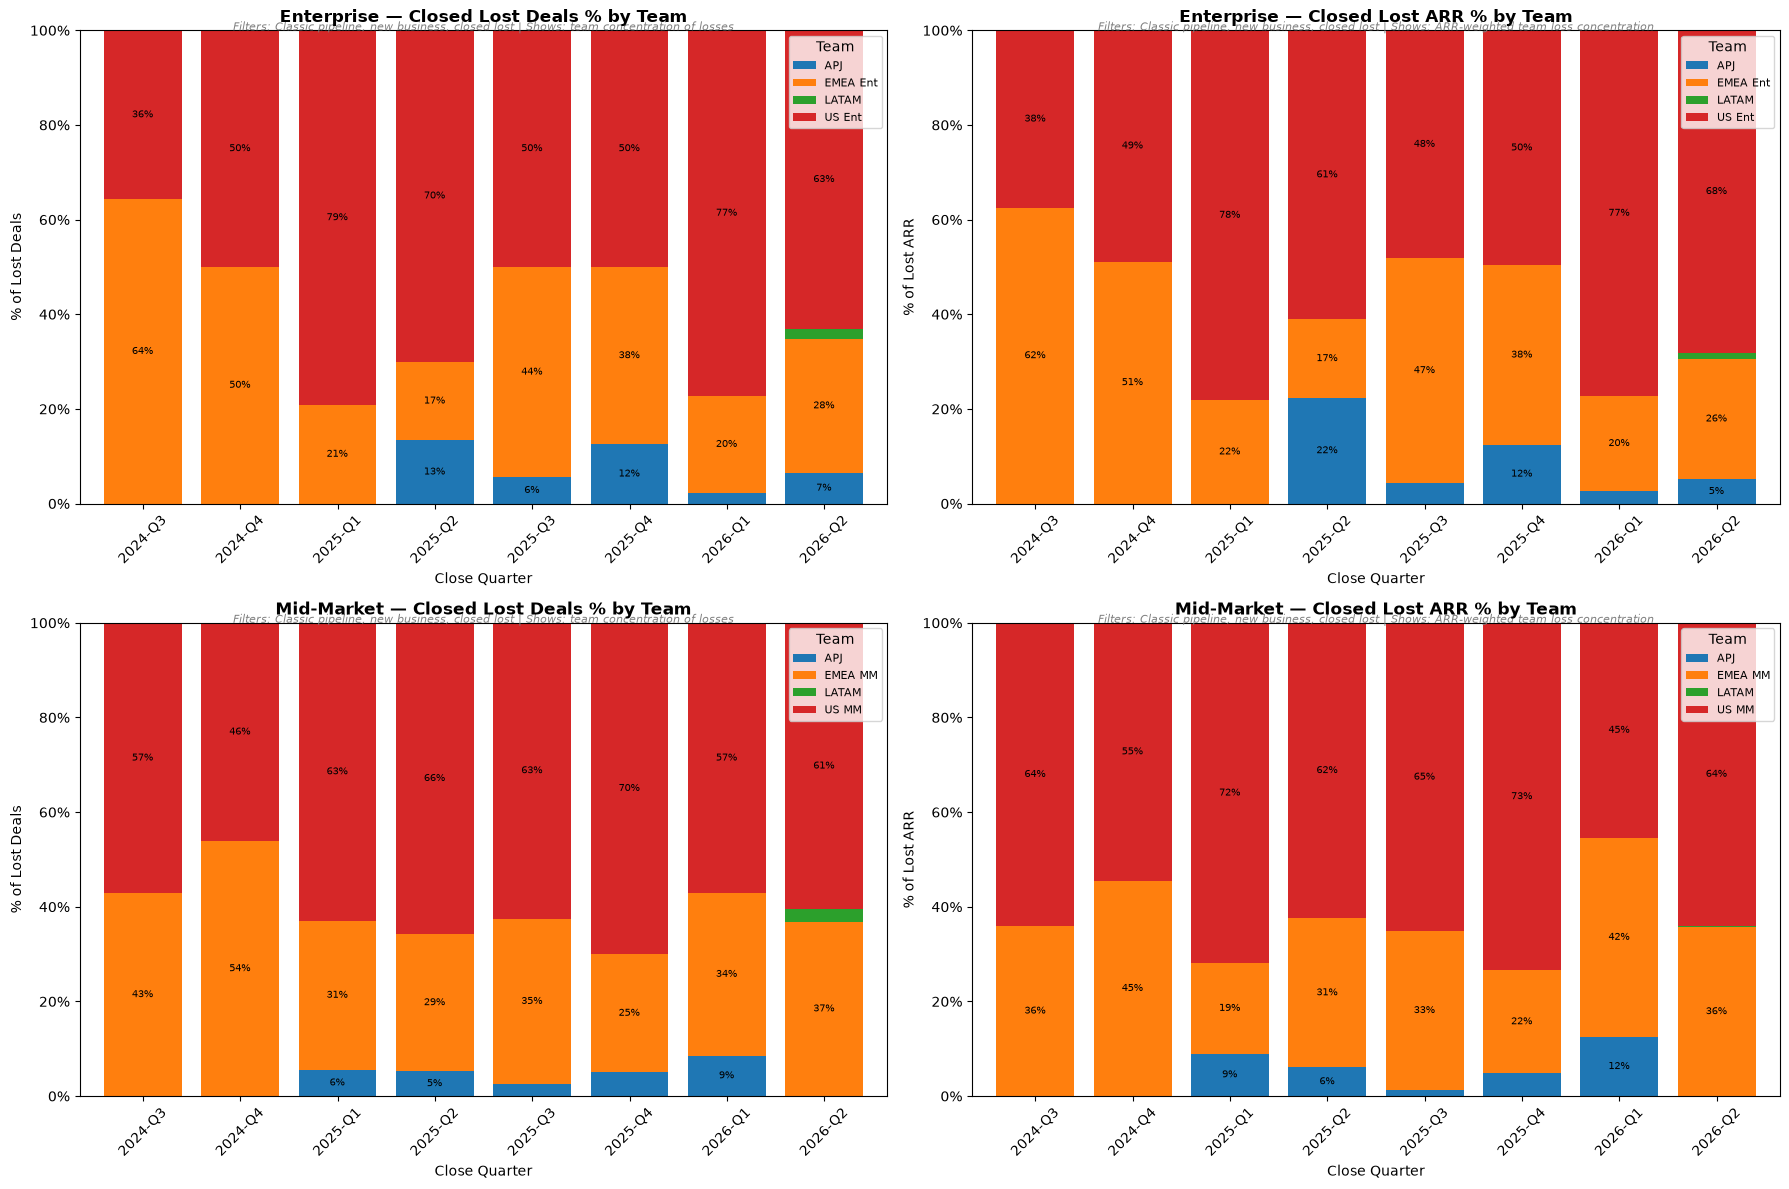

In [57]:
df = chart1_data.copy()
df['LOST_ARR'] = pd.to_numeric(df['LOST_ARR'], errors='coerce').fillna(0)

# Sort quarters
quarter_order = df.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

segments = ['Enterprise', 'Mid-Market']
fig, axes = plt.subplots(len(segments), 2, figsize=(18, 6 * len(segments)))

for row, segment in enumerate(segments):
    seg_df = df[df['SEGMENT'] == segment]

    # Pivot for deal counts
    deals_pivot = seg_df.pivot_table(index='CLOSE_QUARTER', columns='TEAM', values='LOST_DEALS', aggfunc='sum', fill_value=0)
    deals_pivot = deals_pivot.reindex(quarter_order).fillna(0)
    deals_pct = deals_pivot.div(deals_pivot.sum(axis=1), axis=0) * 100
    deals_pct = deals_pct.fillna(0)

    # Pivot for ARR
    arr_pivot = seg_df.pivot_table(index='CLOSE_QUARTER', columns='TEAM', values='LOST_ARR', aggfunc='sum', fill_value=0)
    arr_pivot = arr_pivot.reindex(quarter_order).fillna(0)
    arr_pct = arr_pivot.div(arr_pivot.sum(axis=1), axis=0) * 100
    arr_pct = arr_pct.fillna(0)

    # Left: stacked bar — deal count %
    ax1 = axes[row, 0]
    deals_pct.plot(kind='bar', stacked=True, ax=ax1, width=0.8)
    # Add data labels
    for container in ax1.containers:
        labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
        ax1.bar_label(container, labels=labels, label_type='center', fontsize=7)
    ax1.set_title(f'{segment} — Closed Lost Deals % by Team', fontsize=12, fontweight='bold')
    ax1.text(0.5, 1.0, 'Filters: Classic pipeline, new business, closed lost | Shows: team concentration of losses', transform=ax1.transAxes, fontsize=8, ha='center', color='gray', style='italic')
    ax1.set_ylabel('% of Lost Deals')
    ax1.set_xlabel('Close Quarter')
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.legend(title='Team', fontsize=8)
    ax1.tick_params(axis='x', rotation=45)

    # Right: stacked bar — ARR %
    ax2 = axes[row, 1]
    arr_pct.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
    # Add data labels
    for container in ax2.containers:
        labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
        ax2.bar_label(container, labels=labels, label_type='center', fontsize=7)
    ax2.set_title(f'{segment} — Closed Lost ARR % by Team', fontsize=12, fontweight='bold')
    ax2.text(0.5, 1.0, 'Filters: Classic pipeline, new business, closed lost | Shows: ARR-weighted team loss concentration', transform=ax2.transAxes, fontsize=8, ha='center', color='gray', style='italic')
    ax2.set_ylabel('% of Lost ARR')
    ax2.set_xlabel('Close Quarter')
    ax2.set_ylim(0, 100)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.legend(title='Team', fontsize=8)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

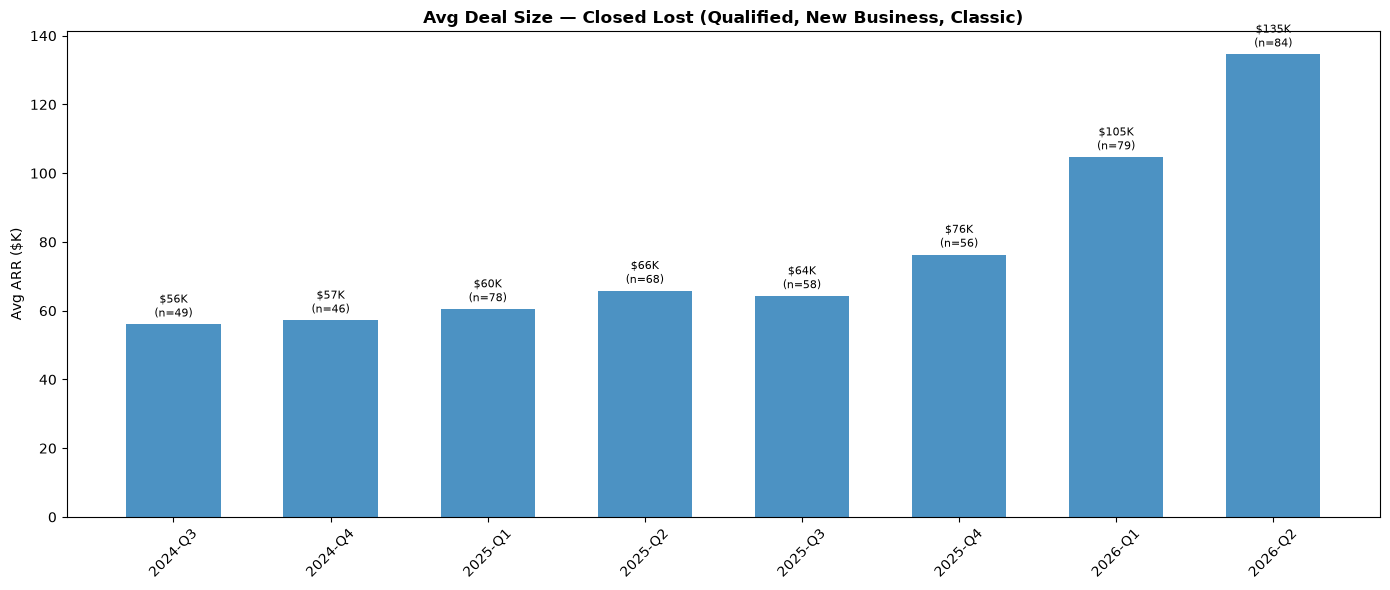

In [58]:
avg_deal_size = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    AVG(d.DEAL_NET_NEW_ARR) AS avg_deal_size,
    COUNT(*) AS deal_count
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
  AND COALESCE(c.COMPANY_NAME, '') NOT ILIKE '%test%'
  AND COALESCE(c.COMPANY_NAME, '') != 'Port'
GROUP BY 1, 2
ORDER BY quarter_sort
""")

df_avg = avg_deal_size.copy()
df_avg['AVG_DEAL_SIZE'] = pd.to_numeric(df_avg['AVG_DEAL_SIZE'], errors='coerce') / 1000
df_avg['DEAL_COUNT'] = pd.to_numeric(df_avg['DEAL_COUNT'], errors='coerce')
df_avg = df_avg.sort_values('QUARTER_SORT')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(df_avg['CLOSE_QUARTER'], df_avg['AVG_DEAL_SIZE'], color='tab:blue', alpha=0.8, width=0.6)
ax.bar_label(bars, labels=[f'${v:.0f}K\n(n={int(n)})' for v, n in zip(df_avg['AVG_DEAL_SIZE'], df_avg['DEAL_COUNT'])],
             fontsize=8, padding=3)

ax.set_title('Avg Deal Size — Closed Lost (Qualified, New Business, Classic)', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg ARR ($K)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 2: Lost Deal Dwell Time

**Hypothesis:** Deals are lingering too long before dying — wasted effort.

Median days from creation to close for lost deals, by segment (Enterprise vs Mid-Market).

In [59]:
chart2_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    CASE
        WHEN d.DEAL_TEAM_NAME ILIKE '%Ent%' THEN 'Enterprise'
        WHEN d.DEAL_TEAM_NAME ILIKE '%MM%' THEN 'Mid-Market'
        ELSE COALESCE(c.SEGMENT, 'Unknown')
    END AS segment,
    MEDIAN(DATEDIFF('day', d.DEAL_CREATED_DATE, {DEAL_CLOSED_DATE_OVERRIDE})) AS median_dwell_days
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, segment
""")

print(f"{len(chart2_data)} rows")
chart2_data

16 rows


,CLOSE_QUARTER,QUARTER_SORT,SEGMENT,MEDIAN_DWELL_DAYS
0,2024-Q3,2024-07-01,Enterprise,131.5
1,2024-Q3,2024-07-01,Mid-Market,69.0
2,2024-Q4,2024-10-01,Enterprise,155.5
3,2024-Q4,2024-10-01,Mid-Market,116.0
4,2025-Q1,2025-01-01,Enterprise,175.0
5,2025-Q1,2025-01-01,Mid-Market,109.0
6,2025-Q2,2025-04-01,Enterprise,149.5
7,2025-Q2,2025-04-01,Mid-Market,104.5
8,2025-Q3,2025-07-01,Enterprise,173.0
9,2025-Q3,2025-07-01,Mid-Market,130.0


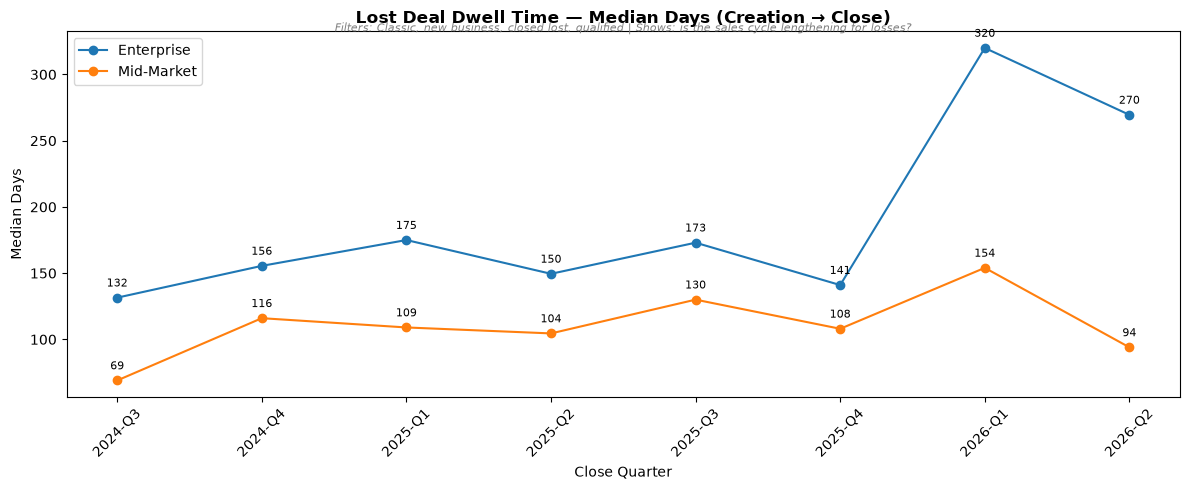

In [60]:
quarter_order = chart2_data.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

fig, ax = plt.subplots(figsize=(12, 5))
for segment in ['Enterprise', 'Mid-Market']:
    seg = chart2_data[chart2_data['SEGMENT'] == segment]
    seg = seg.set_index('CLOSE_QUARTER').reindex(quarter_order)
    ax.plot(seg.index, seg['MEDIAN_DWELL_DAYS'], marker='o', label=segment)
    for x, y in zip(seg.index, seg['MEDIAN_DWELL_DAYS']):
        if pd.notna(y):
            ax.annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8, ha='center')

ax.set_title('Lost Deal Dwell Time — Median Days (Creation → Close)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, closed lost, qualified | Shows: is the sales cycle lengthening for losses?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('Median Days')
ax.set_xlabel('Close Quarter')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Chart 2b: Median Cumulative Time in Each Stage — Enterprise Lost Deals

Median time spent in each pipeline stage, by close quarter. Uses cumulative time columns from HubSpot CSV.

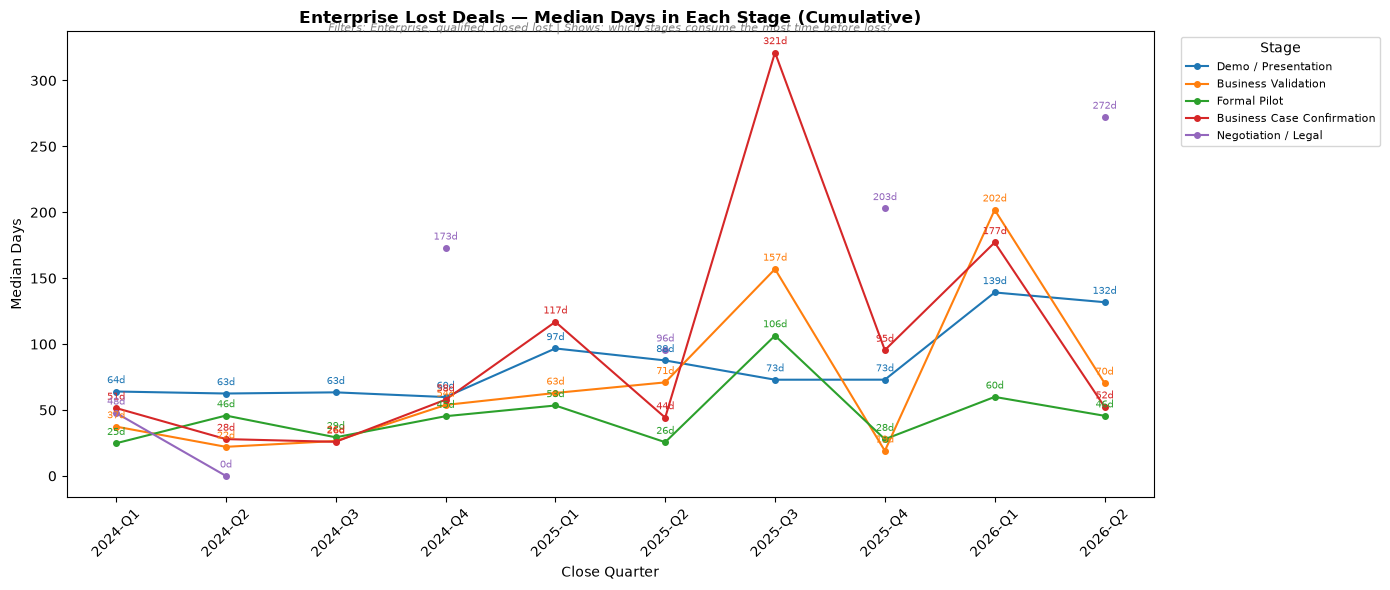

In [61]:
# Parse cumulative time columns (HH:mm:ss format) into days
stage_time_cols = {
    'Cumulative time in "SDR Discovery (Classic)" (HH:mm:ss)': 'SDR Discovery',
    'Cumulative time in "SDR / Omitted  Opp (Classic)" (HH:mm:ss)': 'SDR / Omitted Opp',
    'Cumulative time in "Demo / Presentation  (Classic)" (HH:mm:ss)': 'Demo / Presentation',
    'Cumulative time in "Business Validation (Classic)" (HH:mm:ss)': 'Business Validation',
    'Cumulative time in "Formal Pilot (Classic)" (HH:mm:ss)': 'Formal Pilot',
    'Cumulative time in "Business Case Confirmation (Classic)" (HH:mm:ss)': 'Business Case Confirmation',
    'Cumulative time in "Negotiation / Legal (Classic)" (HH:mm:ss)': 'Negotiation / Legal',
}

def parse_hms_to_days(val):
    """Convert 'HHH:mm:ss' string to days (float)."""
    if pd.isna(val) or str(val).strip() == '':
        return None
    parts = str(val).strip().split(':')
    if len(parts) != 3:
        return None
    try:
        hours, mins, secs = float(parts[0]), float(parts[1]), float(parts[2])
        return (hours + mins/60 + secs/3600) / 24
    except:
        return None

# Filter to Enterprise deals with Qualified Date (using unified segment logic)
ent_deals = hs_deals[
    (hs_deals['segment'] == 'Enterprise')
    & hs_deals['Qualified Date'].notna()
].copy()

# Parse stage times
for col, stage in stage_time_cols.items():
    if col in ent_deals.columns:
        ent_deals[stage] = ent_deals[col].apply(parse_hms_to_days)

# Melt into long format
stage_names = list(stage_time_cols.values())
melted = ent_deals[['Record ID', 'close_quarter', 'Close Date'] + stage_names].melt(
    id_vars=['Record ID', 'close_quarter', 'Close Date'],
    value_vars=stage_names,
    var_name='stage',
    value_name='days_in_stage'
)
melted = melted.dropna(subset=['days_in_stage'])
melted = melted[melted['days_in_stage'] > 0]

# Median by quarter and stage
chart2b_data = melted.groupby(['close_quarter', 'stage']).agg(
    quarter_sort=('Close Date', 'min'),
    median_days=('days_in_stage', 'median'),
    deal_count=('Record ID', 'nunique')
).reset_index()

quarter_order = sorted(chart2b_data['close_quarter'].unique())

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
stage_order = ['Demo / Presentation', 'Business Validation', 'Formal Pilot', 'Business Case Confirmation', 'Negotiation / Legal']
for stage in stage_order:
    subset = chart2b_data[chart2b_data['stage'] == stage].set_index('close_quarter').reindex(quarter_order)
    if subset['median_days'].notna().any():
        line, = ax.plot(subset.index, subset['median_days'], marker='o', markersize=4, label=stage)
        for x, y in zip(subset.index, subset['median_days']):
            if pd.notna(y):
                ax.annotate(f'{y:.0f}d', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, ha='center', color=line.get_color())

ax.set_title('Enterprise Lost Deals — Median Days in Each Stage (Cumulative)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Enterprise, qualified, closed lost | Shows: which stages consume the most time before loss?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('Median Days')
ax.set_xlabel('Close Quarter')
ax.legend(title='Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [62]:
# DEBUG: Explain the dwell vs stage time discrepancy
ent_recent = ent_deals[ent_deals['close_quarter'].isin(['2026-Q1', '2026-Q2'])].copy()
ent_recent['total_dwell'] = (ent_recent['Close Date'] - ent_recent['Create Date']).dt.days

stage_cols = ['Demo / Presentation', 'Business Validation', 'Formal Pilot', 'Business Case Confirmation', 'Negotiation / Legal']
ent_recent['sum_tracked_stages'] = ent_recent[stage_cols].sum(axis=1)
ent_recent['untracked_time'] = ent_recent['total_dwell'] - ent_recent['sum_tracked_stages']

print("Enterprise 2026-Q1/Q2 lost deals:")
print(f"  Count: {len(ent_recent)}")
print(f"  Median total dwell (creation→close): {ent_recent['total_dwell'].median():.0f} days")
print(f"  Median sum of tracked stages: {ent_recent['sum_tracked_stages'].median():.0f} days")
print(f"  Median untracked time (SDR + gaps): {ent_recent['untracked_time'].median():.0f} days")
print()
print("Comparison with earlier quarters:")
ent_older = ent_deals[ent_deals['close_quarter'].isin(['2025-Q1', '2025-Q2'])].copy()
ent_older['total_dwell'] = (ent_older['Close Date'] - ent_older['Create Date']).dt.days
ent_older['sum_tracked_stages'] = ent_older[stage_cols].sum(axis=1)
ent_older['untracked_time'] = ent_older['total_dwell'] - ent_older['sum_tracked_stages']
print(f"  2025-Q1/Q2: dwell={ent_older['total_dwell'].median():.0f}d, tracked={ent_older['sum_tracked_stages'].median():.0f}d, untracked={ent_older['untracked_time'].median():.0f}d")

Enterprise 2026-Q1/Q2 lost deals:
  Count: 89
  Median total dwell (creation→close): 285 days
  Median sum of tracked stages: 253 days
  Median untracked time (SDR + gaps): 18 days

Comparison with earlier quarters:
  2025-Q1/Q2: dwell=160d, tracked=124d, untracked=15d


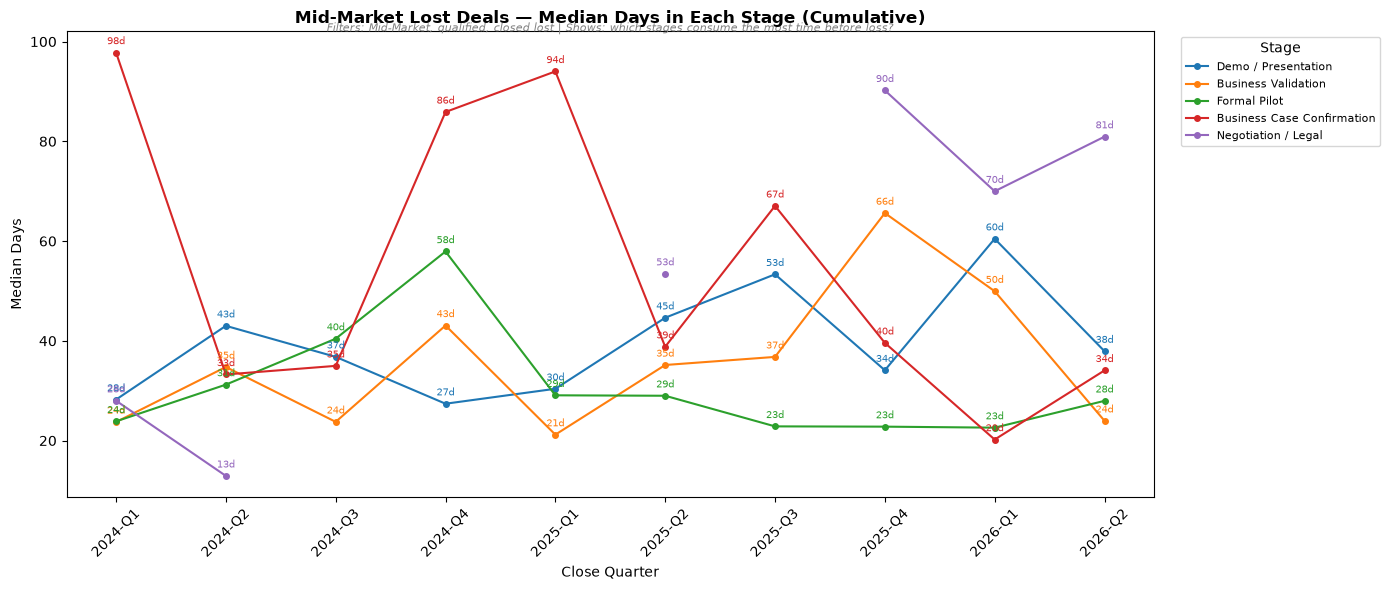

In [63]:
# Chart 2c: Same as 2b but for Mid-Market deals
mm_deals = hs_deals[
    (hs_deals['segment'] == 'Mid-Market')
    & hs_deals['Qualified Date'].notna()
].copy()

for col, stage in stage_time_cols.items():
    if col in mm_deals.columns:
        mm_deals[stage] = mm_deals[col].apply(parse_hms_to_days)

melted_mm = mm_deals[['Record ID', 'close_quarter', 'Close Date'] + stage_names].melt(
    id_vars=['Record ID', 'close_quarter', 'Close Date'],
    value_vars=stage_names,
    var_name='stage',
    value_name='days_in_stage'
)
melted_mm = melted_mm.dropna(subset=['days_in_stage'])
melted_mm = melted_mm[melted_mm['days_in_stage'] > 0]

chart2c_data = melted_mm.groupby(['close_quarter', 'stage']).agg(
    quarter_sort=('Close Date', 'min'),
    median_days=('days_in_stage', 'median'),
    deal_count=('Record ID', 'nunique')
).reset_index()

quarter_order_mm = sorted(chart2c_data['close_quarter'].unique())

fig, ax = plt.subplots(figsize=(14, 6))
stage_order = ['Demo / Presentation', 'Business Validation', 'Formal Pilot', 'Business Case Confirmation', 'Negotiation / Legal']
for stage in stage_order:
    subset = chart2c_data[chart2c_data['stage'] == stage].set_index('close_quarter').reindex(quarter_order_mm)
    if subset['median_days'].notna().any():
        line, = ax.plot(subset.index, subset['median_days'], marker='o', markersize=4, label=stage)
        for x, y in zip(subset.index, subset['median_days']):
            if pd.notna(y):
                ax.annotate(f'{y:.0f}d', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, ha='center', color=line.get_color())

ax.set_title('Mid-Market Lost Deals — Median Days in Each Stage (Cumulative)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Mid-Market, qualified, closed lost | Shows: which stages consume the most time before loss?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('Median Days')
ax.set_xlabel('Close Quarter')
ax.legend(title='Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 3: ARR Shrinkage — Lost Deals

**Hypothesis:** Deals are shrinking their ARR between demo and loss.

Ratio of ARR at loss vs ARR at demo, from property history.  
Ratio < 1 = shrinkage. *Note: Limited to deals with amount history (~4% coverage).*

In [64]:
chart3_data = run_query(f"""
WITH lost_deals AS (
    SELECT
        d.DEAL_CRM_ID,
        {DEAL_CLOSED_DATE_OVERRIDE} AS DEAL_CLOSED_DATE_FIXED,
        CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
        DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort
    FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
    WHERE d.QUALIFIED_DATE IS NOT NULL
      AND d.PIPELINE = 'Classic'
      AND d.DEAL_TYPE = 'newbusiness'
      AND d.ARCHIVED = FALSE
      AND d._DELETED_TIMESTAMP IS NULL
      AND d.IS_CLOSED = TRUE
      AND d.IS_WON = FALSE
      AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
      AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
),
demo_timestamp AS (
    SELECT h.DEALID, MIN(h.TIMESTAMP) AS demo_entered_at
    FROM RAW_PORT_EXTERNAL.AB_HUBSPOT_HISTORY.DEALS_PROPERTY_HISTORY h
    JOIN lost_deals ld ON h.DEALID = ld.DEAL_CRM_ID
    WHERE h.PROPERTY = 'dealstage' AND h.VALUE = '65800980'
    GROUP BY h.DEALID
),
arr_at_demo AS (
    SELECT ld.DEAL_CRM_ID, TRY_TO_DOUBLE(h.VALUE) AS arr_demo
    FROM lost_deals ld
    JOIN demo_timestamp dt ON ld.DEAL_CRM_ID = dt.DEALID
    JOIN RAW_PORT_EXTERNAL.AB_HUBSPOT_HISTORY.DEALS_PROPERTY_HISTORY h
        ON h.DEALID = ld.DEAL_CRM_ID AND h.PROPERTY = 'amount' AND h.TIMESTAMP <= dt.demo_entered_at
    QUALIFY ROW_NUMBER() OVER (PARTITION BY ld.DEAL_CRM_ID ORDER BY h.TIMESTAMP DESC) = 1
),
arr_at_close AS (
    SELECT ld.DEAL_CRM_ID, TRY_TO_DOUBLE(h.VALUE) AS arr_close
    FROM lost_deals ld
    JOIN RAW_PORT_EXTERNAL.AB_HUBSPOT_HISTORY.DEALS_PROPERTY_HISTORY h
        ON h.DEALID = ld.DEAL_CRM_ID AND h.PROPERTY = 'amount' AND h.TIMESTAMP <= ld.DEAL_CLOSED_DATE_FIXED
    QUALIFY ROW_NUMBER() OVER (PARTITION BY ld.DEAL_CRM_ID ORDER BY h.TIMESTAMP DESC) = 1
)
SELECT
    ld.close_quarter,
    ld.quarter_sort,
    MEDIAN(CASE WHEN ad.arr_demo > 0 THEN ac.arr_close / ad.arr_demo END) AS median_ratio,
    COUNT(CASE WHEN ad.arr_demo > 0 THEN 1 END) AS deals_with_data
FROM lost_deals ld
LEFT JOIN arr_at_demo ad ON ld.DEAL_CRM_ID = ad.DEAL_CRM_ID
LEFT JOIN arr_at_close ac ON ld.DEAL_CRM_ID = ac.DEAL_CRM_ID
GROUP BY 1, 2
ORDER BY ld.quarter_sort
""")

print(f"{len(chart3_data)} rows")
chart3_data

8 rows


,CLOSE_QUARTER,QUARTER_SORT,MEDIAN_RATIO,DEALS_WITH_DATA
0,2024-Q3,2024-07-01,NaN,0
1,2024-Q4,2024-10-01,NaN,0
2,2025-Q1,2025-01-01,NaN,0
3,2025-Q2,2025-04-01,NaN,0
4,2025-Q3,2025-07-01,NaN,0
5,2025-Q4,2025-10-01,NaN,0
6,2026-Q1,2026-01-01,NaN,0
7,2026-Q2,2026-04-01,1.0,12


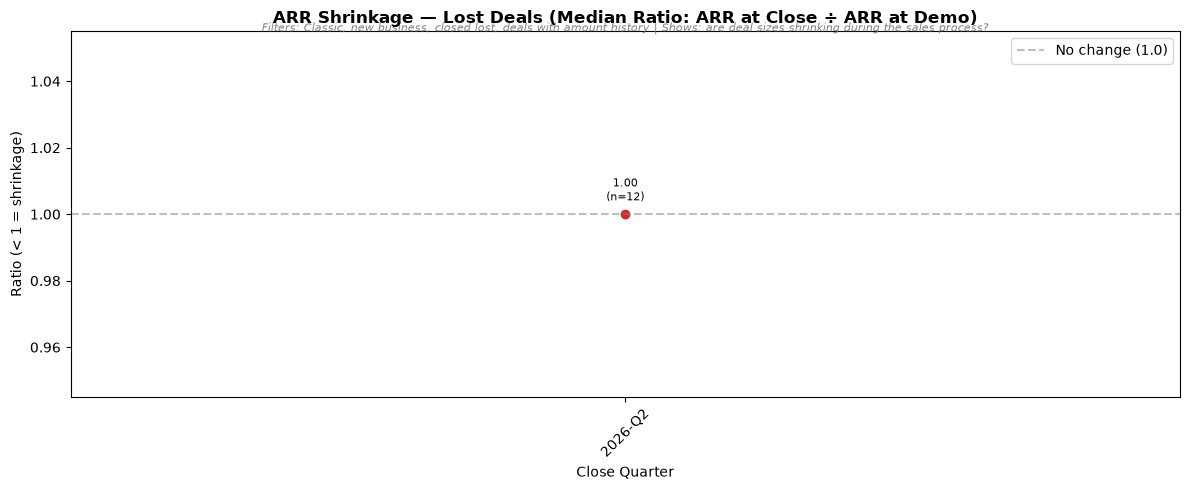

In [65]:
df3 = chart3_data.sort_values('QUARTER_SORT')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df3['CLOSE_QUARTER'], df3['MEDIAN_RATIO'], marker='o', color='tab:red')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='No change (1.0)')
for x, y, n in zip(df3['CLOSE_QUARTER'], df3['MEDIAN_RATIO'], df3['DEALS_WITH_DATA']):
    if pd.notna(y):
        ax.annotate(f'{y:.2f}\n(n={n:.0f})', (x, y), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')

ax.set_title('ARR Shrinkage — Lost Deals (Median Ratio: ARR at Close ÷ ARR at Demo)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, closed lost, deals with amount history | Shows: are deal sizes shrinking during the sales process?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('Ratio (< 1 = shrinkage)')
ax.set_xlabel('Close Quarter')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 4: Owner Changes — Lost Deals

**Hypothesis:** Deals that change owners (post-SDR) are more likely to die.

% of lost deals with ≥1 owner change after leaving SDR stages.

In [66]:
# Chart 4: Owner changes — % of lost ARR by rep change vs no change (qualified deals only)
import csv as _csv

owner_filepath = 'hubspot-crm-exports-deal-owner-2026-07-06.csv'
with open(owner_filepath, 'r', encoding='utf-8') as f:
    reader = _csv.reader(f)
    header = next(reader)
    all_rows = list(reader)

max_cols = max(len(header), max((len(r) for r in all_rows), default=0))
padded = [row + [None] * (max_cols - len(row)) for row in all_rows]
col_names = header + [f'_overflow_{i}' for i in range(max_cols - len(header))]
owner_wide = pd.DataFrame(padded, columns=col_names)
owner_wide['Record ID'] = owner_wide['Record ID'].astype(str).str.strip()

# Count distinct owners per deal (excluding NaN/None/empty)
current_col = next(c for c in col_names if 'Current Value' in str(c))
prev_val_cols = sorted([c for c in col_names if 'Previous Value' in str(c)], key=lambda x: int(x.split('(')[1].split(')')[0]))
overflow_val_cols = [c for c in col_names if str(c).startswith('_overflow_')][::2]
all_owner_cols = [current_col] + prev_val_cols + overflow_val_cols

def count_distinct_owners(row):
    owners = set()
    for col in all_owner_cols:
        val = row.get(col)
        if val and str(val).strip() and str(val).strip().lower() not in ('none', 'nan', ''):
            owners.add(str(val).strip())
    return len(owners)

# Determine if deal had a rep change (different previous owner from current, excluding NaN)
def has_rep_change(row):
    current = str(row[current_col]).strip() if pd.notna(row[current_col]) and str(row[current_col]).strip().lower() not in ('none', 'nan', '') else ''
    if not current:
        return False
    for col in prev_val_cols + overflow_val_cols:
        val = row.get(col)
        if val and str(val).strip() and str(val).strip().lower() not in ('none', 'nan', '') and str(val).strip() != current:
            return True
    return False

owner_wide['distinct_owners'] = owner_wide.apply(count_distinct_owners, axis=1)
owner_wide['had_rep_change'] = owner_wide.apply(has_rep_change, axis=1)

# Filter hs_deals to qualified only, then merge
qualified_deals = hs_deals[hs_deals['Qualified Date'].notna()].copy()
chart4_df = qualified_deals[['Record ID', 'close_quarter', 'Close Date', 'Amount']].merge(
    owner_wide[['Record ID', 'distinct_owners', 'had_rep_change']],
    on='Record ID', how='left'
)
chart4_df['distinct_owners'] = chart4_df['distinct_owners'].fillna(1)
chart4_df['had_rep_change'] = chart4_df['had_rep_change'].fillna(False)
chart4_df['owner_group'] = chart4_df['distinct_owners'].apply(lambda x: 'Rep Change' if x >= 3 else 'No Change')
chart4_df['Amount'] = chart4_df['Amount'].fillna(0)

# Remove deals with no ARR value
chart4_df = chart4_df[chart4_df['Amount'] > 0].reset_index(drop=True)

chart4_data = chart4_df.groupby(['close_quarter', 'owner_group']).agg(
    quarter_sort=('Close Date', 'min'),
    deals=('Record ID', 'count'),
    lost_arr=('Amount', 'sum')
).reset_index()

print(f"{len(chart4_data)} rows, {chart4_df['had_rep_change'].sum()}/{len(chart4_df)} deals had rep change")
chart4_data.head(10)

20 rows, 494/630 deals had rep change


,close_quarter,owner_group,quarter_sort,deals,lost_arr
0,2024-Q1,No Change,2024-01-03 20:05:00,43,1737100.0
1,2024-Q1,Rep Change,2024-01-10 21:41:00,21,910600.0
2,2024-Q2,No Change,2024-04-11 15:39:00,40,2200000.0
3,2024-Q2,Rep Change,2024-05-01 19:43:00,10,557000.0
4,2024-Q3,No Change,2024-07-03 19:36:00,32,1889800.0
5,2024-Q3,Rep Change,2024-07-04 08:43:00,17,854600.0
6,2024-Q4,No Change,2024-10-07 21:50:00,32,1782900.0
7,2024-Q4,Rep Change,2024-10-18 15:40:00,14,846675.0
8,2025-Q1,No Change,2025-01-13 15:39:00,54,3289000.0
9,2025-Q1,Rep Change,2025-01-14 18:59:00,23,1353240.0


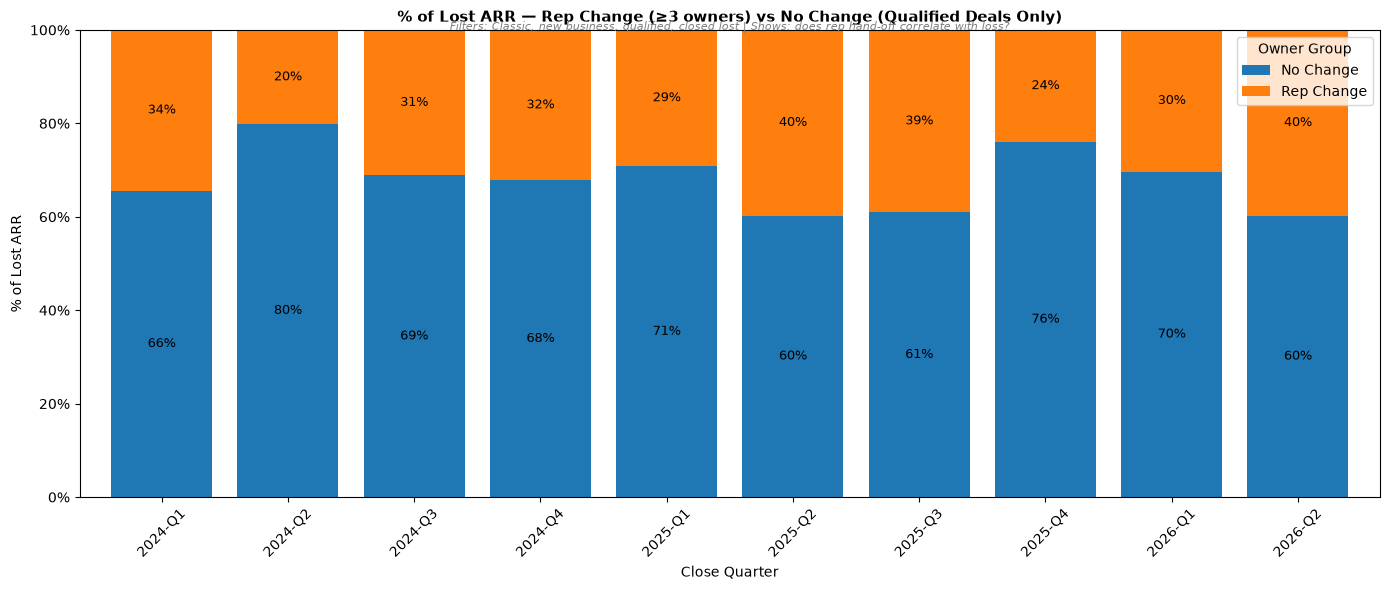

In [67]:
df4 = chart4_data.copy()
quarter_order = sorted(df4['close_quarter'].unique())

pivot4 = df4.pivot_table(index='close_quarter', columns='owner_group', values='lost_arr', aggfunc='sum', fill_value=0)
pivot4 = pivot4.reindex(quarter_order).fillna(0)
pct4 = pivot4.div(pivot4.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct4.plot(kind='bar', stacked=True, ax=ax, width=0.8, color={'Rep Change': 'tab:orange', 'No Change': 'tab:blue'})
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

ax.set_title('% of Lost ARR — Rep Change (≥3 owners) vs No Change (Qualified Deals Only)', fontsize=11, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost | Shows: does rep hand-off correlate with loss?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('Close Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Owner Group')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [68]:
# Raw data: owner change details — find the most recent *different* previous owner
current_col_name = current_col
prev_val_cols_list = prev_val_cols

def get_prev_different_owner(row):
    current = str(row[current_col_name]).strip() if pd.notna(row[current_col_name]) and str(row[current_col_name]).strip().lower() not in ('nan', 'none', '') else ''
    for col in prev_val_cols_list:
        val = row.get(col)
        if pd.notna(val) and str(val).strip() and str(val).strip().lower() not in ('nan', 'none', '') and str(val).strip() != current:
            return str(val).strip()
    return None

owner_wide['prev_diff_owner'] = owner_wide.apply(get_prev_different_owner, axis=1)

# Get team info for previous owner by matching name to hs_deals owner→team mapping
owner_team_map = hs_deals.drop_duplicates('Deal owner').set_index('Deal owner')['HubSpot Team'].to_dict()

chart4_raw = chart4_df[['Record ID', 'close_quarter', 'Amount', 'distinct_owners', 'owner_group']].merge(
    hs_deals[['Record ID', 'Deal Name', 'Deal owner', 'HubSpot Team']],
    on='Record ID', how='left'
).merge(
    owner_wide[['Record ID', 'prev_diff_owner']],
    on='Record ID', how='left'
)
chart4_raw['Prev Owner Team'] = chart4_raw['prev_diff_owner'].map(owner_team_map)
chart4_raw = chart4_raw.rename(columns={'HubSpot Team': 'Current Team', 'Deal owner': 'Current Owner', 'prev_diff_owner': 'Previous Owner'})
chart4_raw = chart4_raw.sort_values(['close_quarter', 'distinct_owners'], ascending=[False, False])

print(f"{len(chart4_raw)} deals with ARR > 0")
display_df = chart4_raw[(chart4_raw['owner_group'] == 'Rep Change') & (chart4_raw['Previous Owner'].notna())]
display_df[['Deal Name', 'close_quarter', 'Amount', 'Current Owner', 'Current Team', 'Previous Owner', 'Prev Owner Team', 'distinct_owners']].head(25)

630 deals with ARR > 0


,Deal Name,close_quarter,Amount,Current Owner,Current Team,Previous Owner,Prev Owner Team,distinct_owners
489,SEB Group,2026-Q2,500000.0,Benjamin Duckworth,EMEA Ent,Ross Geall (Deactivated User),EMEA Ent,9
111,HCA // Pipeline // Q4 2026,2026-Q2,150000.0,Evan Smith,US Ent,Jenny Lucas (Deactivated User),NaN,7
29,Navy Federal Credit Union,2026-Q2,150000.0,Evan Smith,US Ent,Jenny Lucas (Deactivated User),NaN,5
54,Regions Bank,2026-Q2,200000.0,Evan Smith,US Ent,Chris Sweeney,NaN,5
11,OutSystems,2026-Q2,150000.0,Sharon Peretz,EMEA MM,EJ Rauseo,US MM,4
459,Vestas,2026-Q2,100000.0,Benjamin Duckworth,EMEA Ent,Ross Geall (Deactivated User),EMEA Ent,4
1,PSL Group,2026-Q2,50000.0,Jill Countey,US MM,Aaron Marans,NaN,3
6,Alteryx Inc,2026-Q2,200000.0,Jill Countey,US MM,Charity Lee,NaN,3
7,Audacy,2026-Q2,24000.0,Daniel Alper,US MM,Logan Loisel,NaN,3
19,GoFundMe,2026-Q2,200000.0,John Romano,US MM,Jill Countey,US MM,3


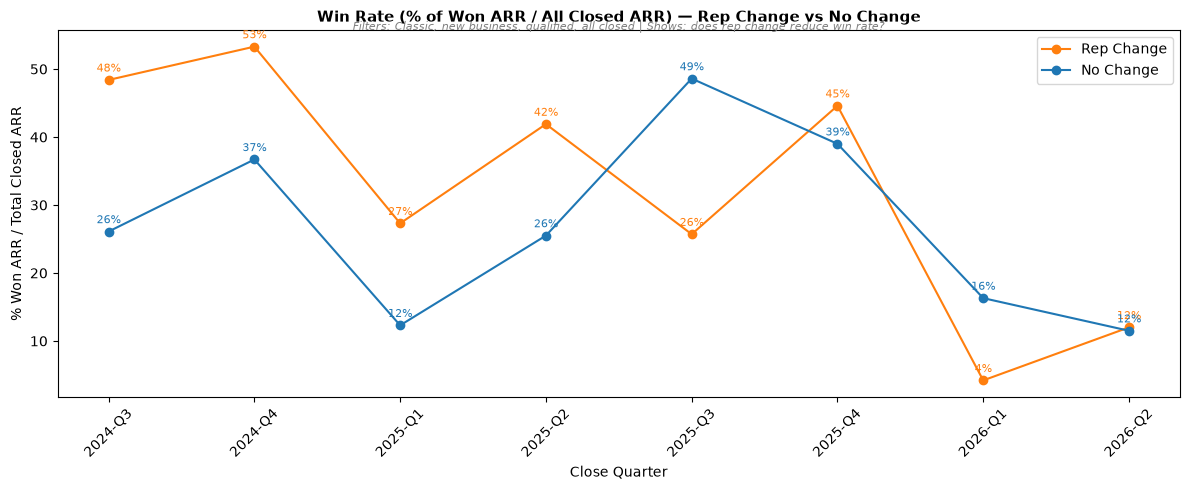

In [69]:
# Chart 4d: Win rate by rep change group
# Get ALL closed deals (won + lost) with owner change info, qualified only
all_closed = run_query(f"""
SELECT
    CAST(d.DEAL_CRM_ID AS VARCHAR) AS deal_id,
    CONCAT(YEAR(d.DEAL_CLOSED_DATE), '-Q', QUARTER(d.DEAL_CLOSED_DATE)) AS close_quarter,
    DATE_TRUNC('quarter', d.DEAL_CLOSED_DATE) AS quarter_sort,
    d.DEAL_NET_NEW_ARR,
    d.IS_WON
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.DEAL_NET_NEW_ARR > 0
  AND d.DEAL_CLOSED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND d.DEAL_CLOSED_DATE <= '2026-06-30'
""")

# Merge with owner change data
all_closed['DEAL_NET_NEW_ARR'] = pd.to_numeric(all_closed['DEAL_NET_NEW_ARR'], errors='coerce').fillna(0)
all_closed = all_closed[all_closed['DEAL_NET_NEW_ARR'] > 0].reset_index(drop=True)
all_closed = all_closed.merge(
    owner_wide[['Record ID', 'distinct_owners']].rename(columns={'Record ID': 'DEAL_ID'}),
    on='DEAL_ID', how='left'
)
all_closed['distinct_owners'] = all_closed['distinct_owners'].fillna(1)
all_closed['owner_group'] = all_closed['distinct_owners'].apply(lambda x: 'Rep Change' if x >= 3 else 'No Change')

# Compute win rate per group per quarter
chart4d = all_closed.groupby(['CLOSE_QUARTER', 'QUARTER_SORT', 'owner_group']).agg(
    total_arr=('DEAL_NET_NEW_ARR', 'sum'),
    won_arr=('DEAL_NET_NEW_ARR', lambda x: x[all_closed.loc[x.index, 'IS_WON'] == True].sum())
).reset_index()
chart4d['win_rate'] = (100.0 * chart4d['won_arr'] / chart4d['total_arr']).round(1)

# Plot
quarter_order = sorted(chart4d['CLOSE_QUARTER'].unique())
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Rep Change': 'tab:orange', 'No Change': 'tab:blue'}
for group in ['Rep Change', 'No Change']:
    subset = chart4d[chart4d['owner_group'] == group].set_index('CLOSE_QUARTER').reindex(quarter_order)
    line, = ax.plot(subset.index, subset['win_rate'], marker='o', label=group, color=colors[group])
    for x, y in zip(subset.index, subset['win_rate']):
        if pd.notna(y):
            ax.annotate(f'{y:.0f}%', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=8, ha='center', color=line.get_color())

ax.set_title('Win Rate (% of Won ARR / All Closed ARR) — Rep Change vs No Change', fontsize=11, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, all closed | Shows: does rep change reduce win rate?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% Won ARR / Total Closed ARR')
ax.set_xlabel('Close Quarter')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

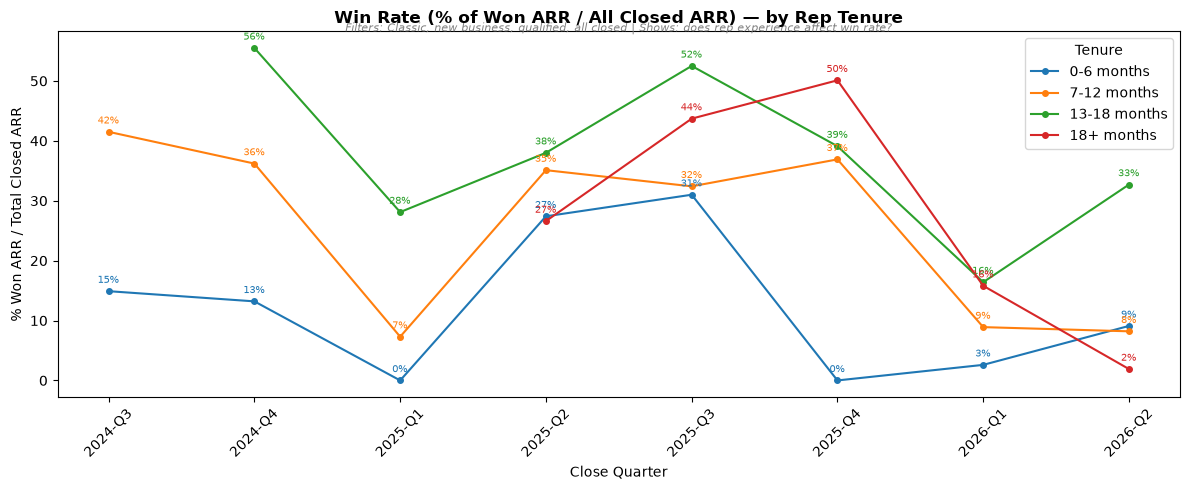

In [70]:
# Chart 4e: Win rate by rep tenure group
chart4e_data = run_query(f"""
SELECT
    CONCAT(YEAR(d.DEAL_CLOSED_DATE), '-Q', QUARTER(d.DEAL_CLOSED_DATE)) AS close_quarter,
    DATE_TRUNC('quarter', d.DEAL_CLOSED_DATE) AS quarter_sort,
    DATEDIFF('month', e.ORIGINAL_START_DATE, d.DEAL_CLOSED_DATE) AS tenure_months,
    d.DEAL_NET_NEW_ARR,
    d.IS_WON
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
JOIN PORT_ANALYTICS_PROD.DWH.DIM_EMPLOYEE e ON d.SK_SALES_OWNER = e.SK_EMPLOYEE
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.DEAL_NET_NEW_ARR > 0
  AND d.DEAL_CLOSED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND d.DEAL_CLOSED_DATE <= '2026-06-30'
  AND e.ORIGINAL_START_DATE IS NOT NULL
""")

df4e = chart4e_data.copy()
df4e['DEAL_NET_NEW_ARR'] = pd.to_numeric(df4e['DEAL_NET_NEW_ARR'], errors='coerce').fillna(0)
df4e['TENURE_MONTHS'] = pd.to_numeric(df4e['TENURE_MONTHS'], errors='coerce')

def tenure_bucket(m):
    if pd.isna(m): return 'Unknown'
    if m <= 6: return '0-6 months'
    if m <= 12: return '7-12 months'
    if m <= 18: return '13-18 months'
    return '18+ months'

df4e['tenure_group'] = df4e['TENURE_MONTHS'].apply(tenure_bucket)
quarter_order = sorted(df4e['CLOSE_QUARTER'].unique())

# Win rate by tenure group by quarter
win_rate_tenure = df4e.groupby(['CLOSE_QUARTER', 'tenure_group']).agg(
    total_arr=('DEAL_NET_NEW_ARR', 'sum'),
    won_arr=('DEAL_NET_NEW_ARR', lambda x: x[df4e.loc[x.index, 'IS_WON'] == True].sum())
).reset_index()
win_rate_tenure['win_rate'] = (100.0 * win_rate_tenure['won_arr'] / win_rate_tenure['total_arr']).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
tenure_order = ['0-6 months', '7-12 months', '13-18 months', '18+ months']
for group in tenure_order:
    subset = win_rate_tenure[win_rate_tenure['tenure_group'] == group].set_index('CLOSE_QUARTER').reindex(quarter_order)
    line, = ax.plot(subset.index, subset['win_rate'], marker='o', markersize=4, label=group)
    for x, y in zip(subset.index, subset['win_rate']):
        if pd.notna(y):
            ax.annotate(f'{y:.0f}%', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, ha='center', color=line.get_color())

ax.set_title('Win Rate (% of Won ARR / All Closed ARR) — by Rep Tenure', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, all closed | Shows: does rep experience affect win rate?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% Won ARR / Total Closed ARR')
ax.set_xlabel('Close Quarter')
ax.legend(title='Tenure')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Chart 4b: Rep Tenure at Deal Close

**Hypothesis:** Newer reps lose more deals.

% of lost ARR by rep tenure (months from ORIGINAL_START_DATE to DEAL_CLOSED_DATE), grouped into buckets.

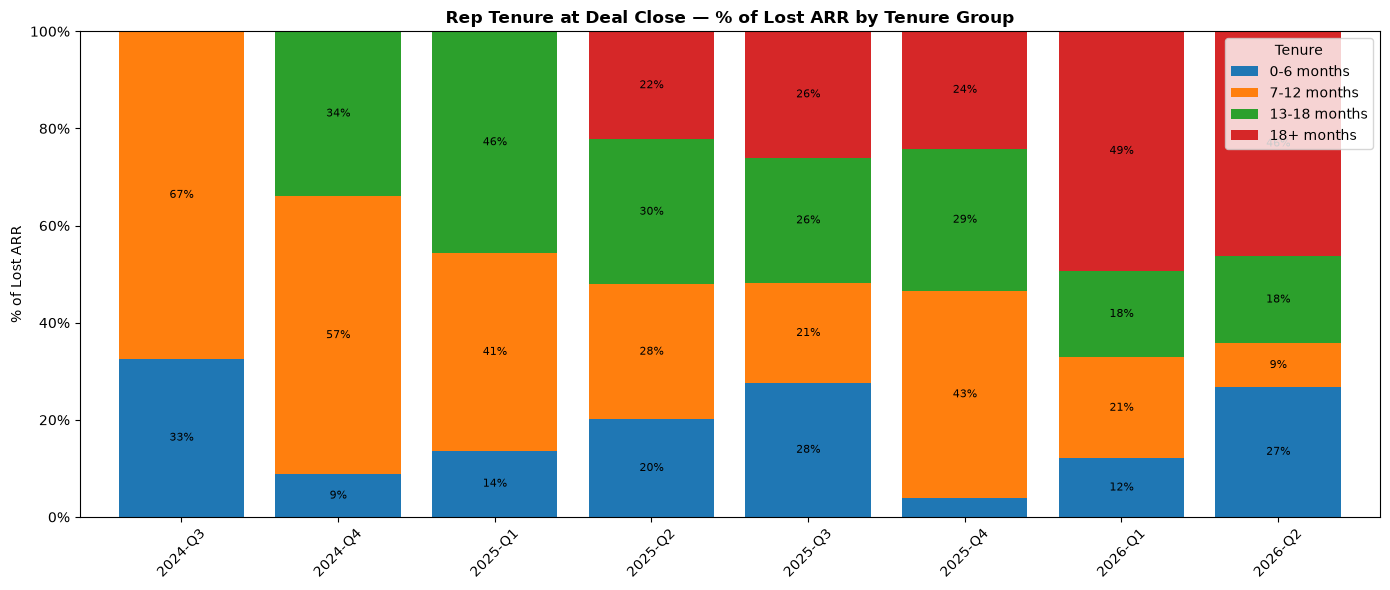

In [71]:
chart4b_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    DATEDIFF('month', e.ORIGINAL_START_DATE, {DEAL_CLOSED_DATE_OVERRIDE}) AS tenure_months,
    d.DEAL_NET_NEW_ARR
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
JOIN PORT_ANALYTICS_PROD.DWH.DIM_EMPLOYEE e ON d.SK_SALES_OWNER = e.SK_EMPLOYEE
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
  AND e.ORIGINAL_START_DATE IS NOT NULL
""")

df4b = chart4b_data.copy()
df4b['DEAL_NET_NEW_ARR'] = pd.to_numeric(df4b['DEAL_NET_NEW_ARR'], errors='coerce').fillna(0)
df4b['TENURE_MONTHS'] = pd.to_numeric(df4b['TENURE_MONTHS'], errors='coerce')

# Bucket tenure
def tenure_bucket(m):
    if pd.isna(m): return 'Unknown'
    if m <= 6: return '0-6 months'
    if m <= 12: return '7-12 months'
    if m <= 18: return '13-18 months'
    return '18+ months'

df4b['tenure_group'] = df4b['TENURE_MONTHS'].apply(tenure_bucket)
quarter_order = df4b.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

# Pivot
pivot4b = df4b.pivot_table(index='CLOSE_QUARTER', columns='tenure_group', values='DEAL_NET_NEW_ARR', aggfunc='sum', fill_value=0)
# Reorder columns logically
col_order = ['0-6 months', '7-12 months', '13-18 months', '18+ months']
pivot4b = pivot4b.reindex(columns=[c for c in col_order if c in pivot4b.columns]).reindex(quarter_order).fillna(0)
pct4b = pivot4b.div(pivot4b.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct4b.plot(kind='bar', stacked=True, ax=ax, width=0.8)
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Rep Tenure at Deal Close — % of Lost ARR by Tenure Group', fontsize=12, fontweight='bold')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Tenure', loc='upper right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# Chart 4c: Raw data — rep tenure for 2026-Q2 lost deals
chart4c_data = run_query("""
SELECT
    e.DISPLAY_NAME AS rep,
    d.DEAL_NAME AS deal,
    d.DEAL_NET_NEW_ARR AS amount,
    e.ORIGINAL_START_DATE,
    d.DEAL_CLOSED_DATE,
    DATEDIFF('month', e.ORIGINAL_START_DATE, d.DEAL_CLOSED_DATE) AS tenure_months
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
JOIN PORT_ANALYTICS_PROD.DWH.DIM_EMPLOYEE e ON d.SK_SALES_OWNER = e.SK_EMPLOYEE
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND d.DEAL_CLOSED_DATE >= '2026-04-01'
  AND d.DEAL_CLOSED_DATE <= '2026-06-30'
  AND e.ORIGINAL_START_DATE IS NOT NULL
ORDER BY d.DEAL_CLOSED_DATE DESC, tenure_months DESC, d.DEAL_NET_NEW_ARR DESC
""")

print(f"{len(chart4c_data)} deals in 2026-Q2")
chart4c_data

78 deals in 2026-Q2


,REP,DEAL,AMOUNT,ORIGINAL_START_DATE,DEAL_CLOSED_DATE,TENURE_MONTHS
0,Daniel Alper,Collectors Holdings Inc,150000.0,2024-09-12,2026-06-30,21
1,Scott Dunion,Rio Tinto,99950.0,2024-11-26,2026-06-30,19
2,John Romano,Smartsheet,250000.0,2024-05-20,2026-06-26,25
3,Ignacio De Loera,Apex Global Mobility,14400.0,2026-01-12,2026-06-26,5
4,James Butcher,Finova,72000.0,2026-03-03,2026-06-24,3
...,...,...,...,...,...,...
73,Tom Skarzynski,Wiley,300000.0,2024-01-03,2026-04-07,27
74,Jill Countey,Q2,200000.0,2025-01-06,2026-04-07,15
75,Jill Countey,Navitus,60000.0,2025-01-06,2026-04-03,15
76,Benjamin Duckworth,Zalando,250000.0,2023-11-20,2026-04-02,29


---
## Chart 5: Competitive Losses

**Hypothesis:** More deals are being lost to competition.

% of lost deals/ARR where CLOSED_LOST_REASON contains "Competition", trended by quarter.

In [73]:
# Chart 5: Use hs_deals directly for competitor data
df5_src = hs_deals[['Record ID', 'close_quarter', 'Close Date', 'Amount', 'Evaluated competitors']].copy()
df5_src['has_competitor'] = df5_src['Evaluated competitors'].notna() & (df5_src['Evaluated competitors'] != 'None')
df5_src['Amount'] = df5_src['Amount'].fillna(0)
df5_src['quarter_sort'] = df5_src['Close Date']

chart5_data = df5_src.groupby('close_quarter').agg(
    quarter_sort=('quarter_sort', 'min'),
    total_lost=('Record ID', 'count'),
    competitive_deals=('has_competitor', 'sum'),
    total_arr=('Amount', 'sum'),
    competitive_arr=('Amount', lambda x: x[df5_src.loc[x.index, 'has_competitor']].sum())
).reset_index()
chart5_data['pct_deals'] = (100.0 * chart5_data['competitive_deals'] / chart5_data['total_lost']).round(1)
chart5_data['pct_arr'] = (100.0 * chart5_data['competitive_arr'] / chart5_data['total_arr'].replace(0, np.nan)).round(1)

print(f"{len(chart5_data)} quarters, {df5_src['has_competitor'].sum()} deals with competitor data")
chart5_data

10 quarters, 365 deals with competitor data


,close_quarter,quarter_sort,total_lost,competitive_deals,total_arr,competitive_arr,pct_deals,pct_arr
0,2024-Q1,2024-01-03 20:05:00,64,47,2647700.0,2151600.0,73.4,81.3
1,2024-Q2,2024-04-11 15:39:00,50,39,2757000.0,2096000.0,78.0,76.0
2,2024-Q3,2024-07-03 19:36:00,49,32,2744400.0,1913600.0,65.3,69.7
3,2024-Q4,2024-10-07 21:50:00,46,35,2629575.0,1999575.0,76.1,76.0
4,2025-Q1,2025-01-13 15:39:00,77,64,4642240.0,3939240.0,83.1,84.9
5,2025-Q2,2025-04-01 00:21:00,69,41,4544570.0,2661710.0,59.4,58.6
6,2025-Q3,2025-07-01 12:02:00,60,27,3725600.0,1963000.0,45.0,52.7
7,2025-Q4,2025-10-01 17:48:00,56,22,4272915.0,1798000.0,39.3,42.1
8,2026-Q1,2026-01-01 13:18:00,79,31,8266050.0,3586750.0,39.2,43.4
9,2026-Q2,2026-04-01 01:09:00,82,27,11702150.0,4772550.0,32.9,40.8


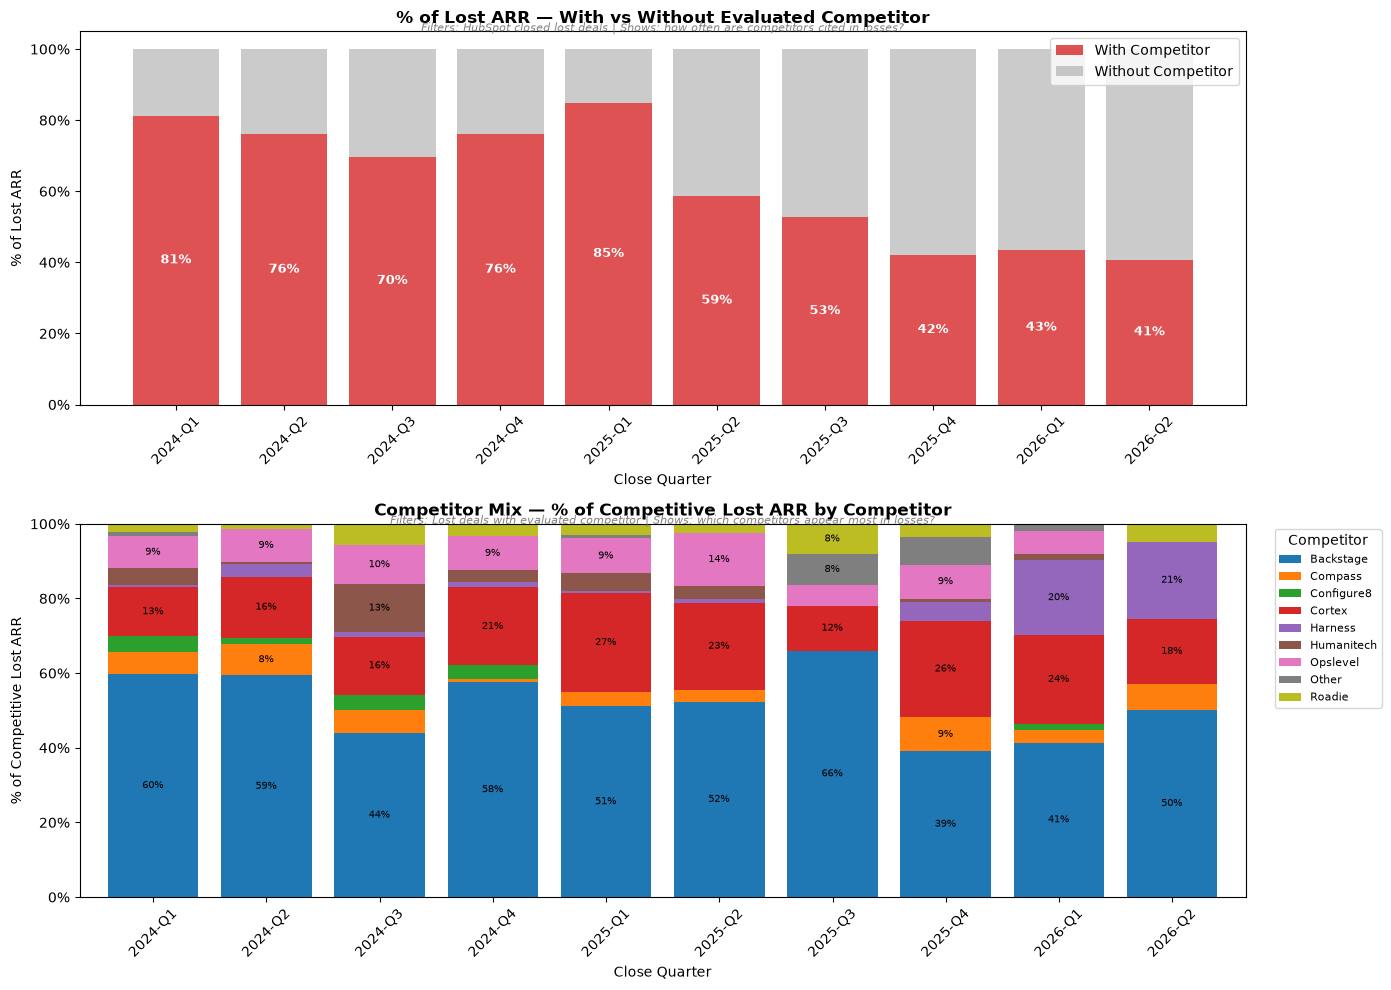

In [74]:
df5 = chart5_data.sort_values('quarter_sort')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top chart: % of lost ARR with vs without evaluated competitor ---
ax1 = axes[0]
ax1.bar(df5['close_quarter'], df5['pct_arr'], color='tab:red', alpha=0.8, label='With Competitor')
ax1.bar(df5['close_quarter'], 100 - df5['pct_arr'], bottom=df5['pct_arr'], color='tab:gray', alpha=0.4, label='Without Competitor')
for x, y in zip(df5['close_quarter'], df5['pct_arr']):
    if pd.notna(y):
        ax1.annotate(f'{y:.0f}%', (x, y / 2), fontsize=9, ha='center', va='center', color='white', fontweight='bold')
ax1.set_title('% of Lost ARR — With vs Without Evaluated Competitor', fontsize=12, fontweight='bold')
ax1.text(0.5, 1.0, 'Filters: HubSpot closed lost deals | Shows: how often are competitors cited in losses?', transform=ax1.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax1.set_ylabel('% of Lost ARR')
ax1.set_xlabel('Close Quarter')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- Bottom chart: Competitor mix (% of competitive ARR by competitor) ---
# Explode semicolon-separated competitors
df5_detail = hs_deals[['Record ID', 'close_quarter', 'Amount', 'Evaluated competitors']].copy()
df5_detail = df5_detail[df5_detail['Evaluated competitors'].notna() & (df5_detail['Evaluated competitors'] != 'None')]
df5_detail['Amount'] = df5_detail['Amount'].fillna(0)

# Split multi-value competitors
exploded = df5_detail.assign(competitor=df5_detail['Evaluated competitors'].str.split('; ')).explode('competitor')
exploded['competitor'] = exploded['competitor'].str.strip()
exploded = exploded[exploded['competitor'].notna() & (exploded['competitor'] != '') & (exploded['competitor'] != 'None')]

# Get top competitors by total ARR
top_competitors = exploded.groupby('competitor')['Amount'].sum().nlargest(8).index.tolist()
exploded['competitor_group'] = exploded['competitor'].where(exploded['competitor'].isin(top_competitors), 'Other')

# Pivot
comp_pivot = exploded.groupby(['close_quarter', 'competitor_group'])['Amount'].sum().reset_index()
quarter_order = sorted(comp_pivot['close_quarter'].unique())
pivot_comp = comp_pivot.pivot_table(index='close_quarter', columns='competitor_group', values='Amount', aggfunc='sum', fill_value=0)
pivot_comp = pivot_comp.reindex(quarter_order).fillna(0)
pct_comp = pivot_comp.div(pivot_comp.sum(axis=1), axis=0) * 100

ax2 = axes[1]
pct_comp.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
for container in ax2.containers:
    labels = [f'{v:.0f}%' if v > 8 else '' for v in container.datavalues]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=7)
ax2.set_title('Competitor Mix — % of Competitive Lost ARR by Competitor', fontsize=12, fontweight='bold')
ax2.text(0.5, 1.0, 'Filters: Lost deals with evaluated competitor | Shows: which competitors appear most in losses?', transform=ax2.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax2.set_ylabel('% of Competitive Lost ARR')
ax2.set_xlabel('Close Quarter')
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(title='Competitor', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Chart 6: Lost Deal Source Mix

**Hypothesis:** The source mix is shifting toward lower-quality channels.

Share of lost deals by `MEGA_SOURCE`, trended by quarter.

In [75]:
chart6_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    COALESCE(d.MEGA_SOURCE, 'Unknown') AS source,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, source
""")

print(f"{len(chart6_data)} rows")
chart6_data.head()

34 rows


,CLOSE_QUARTER,QUARTER_SORT,SOURCE,LOST_ARR
0,2024-Q3,2024-07-01,Inbound,2463600.00
1,2024-Q3,2024-07-01,Outbound Sales,84000.00
2,2024-Q3,2024-07-01,Outbount SDR,120000.00
3,2024-Q3,2024-07-01,Referrals,76800.00
4,2024-Q4,2024-10-01,Inbound,2243575.00


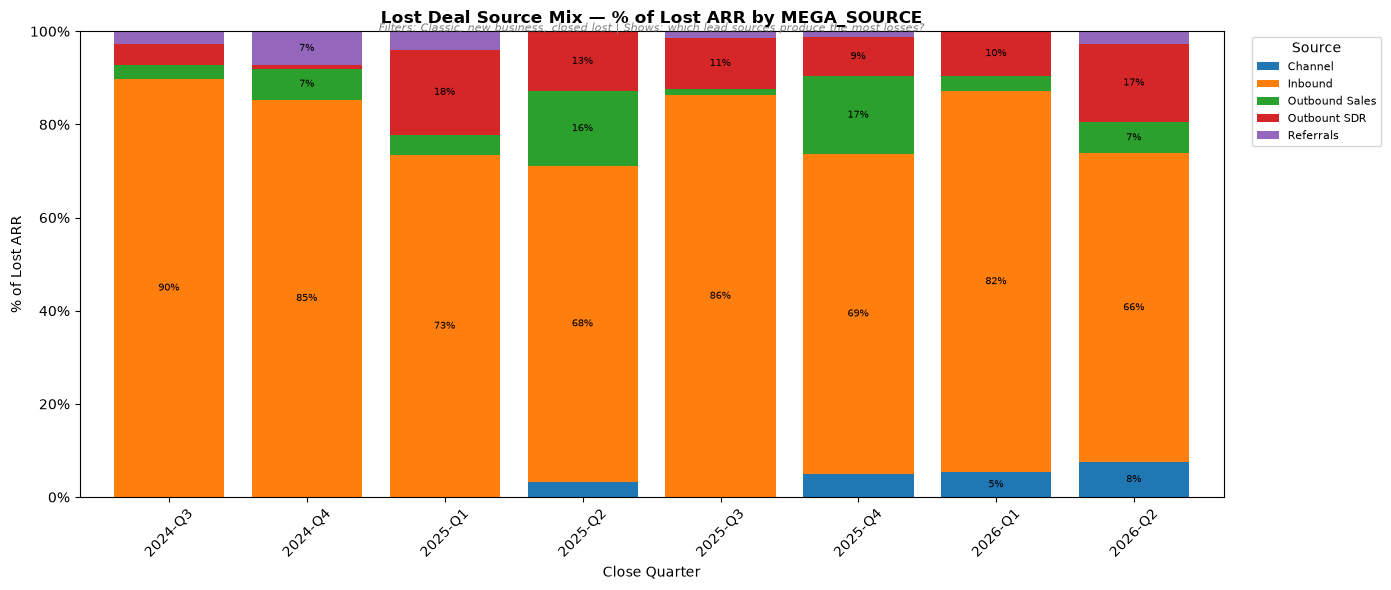

In [76]:
df6 = chart6_data.copy()
df6['LOST_ARR'] = pd.to_numeric(df6['LOST_ARR'], errors='coerce').fillna(0)
quarter_order = df6.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

pivot6 = df6.pivot_table(index='CLOSE_QUARTER', columns='SOURCE', values='LOST_ARR', aggfunc='sum', fill_value=0)
pivot6 = pivot6.reindex(quarter_order).fillna(0)
pct6 = pivot6.div(pivot6.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct6.plot(kind='bar', stacked=True, ax=ax, width=0.8)
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=7)

ax.set_title('Lost Deal Source Mix — % of Lost ARR by MEGA_SOURCE', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, closed lost | Shows: which lead sources produce the most losses?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('Close Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Source', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 7: Qualification Speed

**Hypothesis:** Qualification bar is loosening — deals are being qualified faster without proper vetting.

Median days from creation to qualification, by creation quarter cohort.

In [77]:
chart7_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    MEDIAN(DATEDIFF('day', d.DEAL_CREATED_DATE, d.QUALIFIED_DATE)) AS median_days_to_qualify
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2
ORDER BY quarter_sort
""")

print(f"{len(chart7_data)} rows")
chart7_data

8 rows


,CLOSE_QUARTER,QUARTER_SORT,MEDIAN_DAYS_TO_QUALIFY
0,2024-Q3,2024-07-01,12.0
1,2024-Q4,2024-10-01,7.0
2,2025-Q1,2025-01-01,11.0
3,2025-Q2,2025-04-01,12.0
4,2025-Q3,2025-07-01,15.0
5,2025-Q4,2025-10-01,6.0
6,2026-Q1,2026-01-01,15.0
7,2026-Q2,2026-04-01,12.0


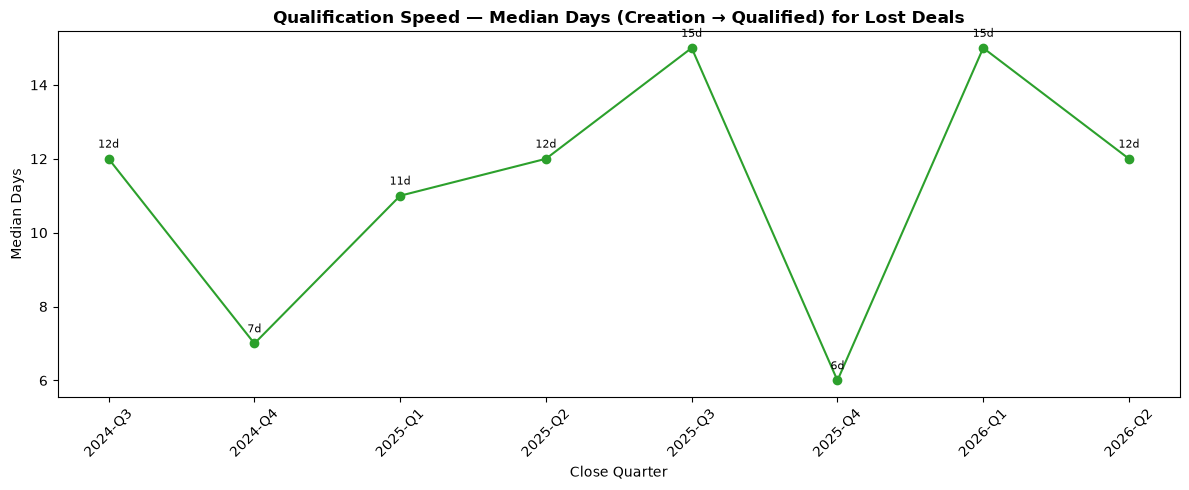

In [78]:
df7 = chart7_data.sort_values('QUARTER_SORT')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df7['CLOSE_QUARTER'], df7['MEDIAN_DAYS_TO_QUALIFY'], marker='o', color='tab:green')
for x, y in zip(df7['CLOSE_QUARTER'], df7['MEDIAN_DAYS_TO_QUALIFY']):
    if pd.notna(y):
        ax.annotate(f'{y:.0f}d', (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8, ha='center')

ax.set_title('Qualification Speed — Median Days (Creation → Qualified) for Lost Deals', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Days')
ax.set_xlabel('Close Quarter')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 16: Median Days to Close — Lost Deals

Overall trend of how long lost deals take to die (contrast with Chart 2's segment split).

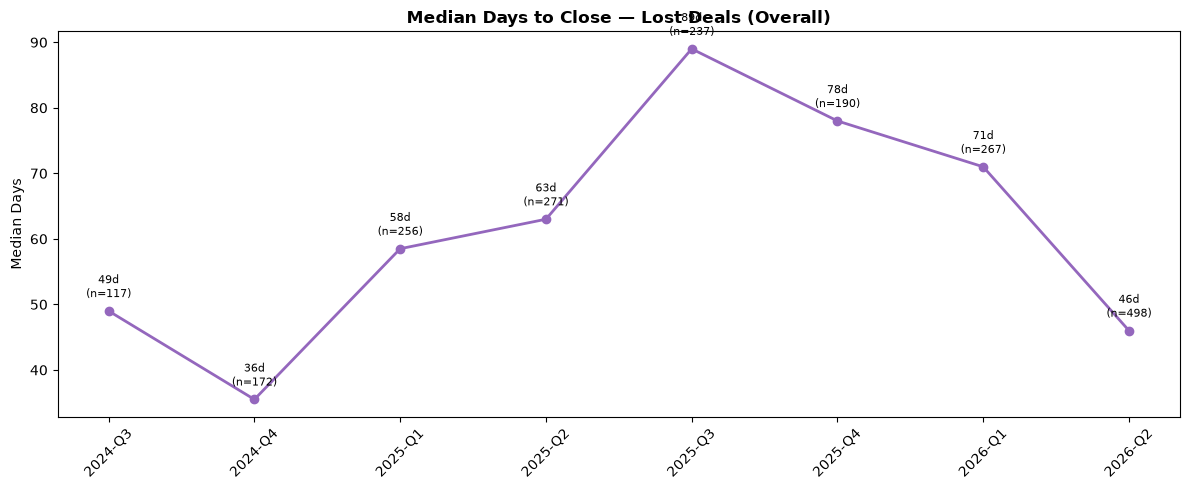

In [79]:
chart16_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    MEDIAN(DATEDIFF('day', d.DEAL_CREATED_DATE, {DEAL_CLOSED_DATE_OVERRIDE})) AS median_days,
    COUNT(*) AS deal_count
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2
ORDER BY quarter_sort
""")

df16 = chart16_data.sort_values('QUARTER_SORT')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df16['CLOSE_QUARTER'], df16['MEDIAN_DAYS'], marker='o', color='tab:purple', linewidth=2)
for x, y, n in zip(df16['CLOSE_QUARTER'], df16['MEDIAN_DAYS'], df16['DEAL_COUNT']):
    if pd.notna(y):
        ax.annotate(f'{y:.0f}d\n(n={n})', (x, y), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')

ax.set_title('Median Days to Close — Lost Deals (Overall)', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Days')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 18: Stage Before Closed

**Hypothesis:** Deals are dying earlier in the pipeline (before reaching advanced stages).

% of lost ARR by last stage reached before loss. Only deals with ≥2 stage history entries included (26/78 in Q2 2026).  
Uses second-to-last `dealstage` entry from property history (the entry before the `closedlost` transition).

In [80]:
# Chart 18: Use hs_deals directly for stage-before-closed
df18_src = hs_deals[['Record ID', 'close_quarter', 'Close Date', 'Amount', 'Deal Stage Before Closed']].copy()
df18_src['Deal Stage Before Closed'] = df18_src['Deal Stage Before Closed'].fillna('Unknown')
df18_src['Amount'] = df18_src['Amount'].fillna(0)

chart18_data = df18_src.groupby(['close_quarter', 'Deal Stage Before Closed']).agg(
    quarter_sort=('Close Date', 'min'),
    deals=('Record ID', 'count'),
    lost_arr=('Amount', 'sum')
).reset_index().rename(columns={'Deal Stage Before Closed': 'last_stage'})

print(f"{len(chart18_data)} rows, {df18_src['Record ID'].nunique()} deals")
print(f"Stages: {chart18_data['last_stage'].unique()}")
chart18_data.head(10)

47 rows, 632 deals
Stages: <ArrowStringArray>
['Business case confirmation',        'Demo / Presentation',
               'Formal Pilot',        'Negotiation / Legal',
                 'Pilot Prep']
Length: 5, dtype: str


,close_quarter,last_stage,quarter_sort,deals,lost_arr
0,2024-Q1,Business case confirmation,2024-02-12 20:35:00,4,137100.0
1,2024-Q1,Demo / Presentation,2024-01-03 20:05:00,35,1533600.0
2,2024-Q1,Formal Pilot,2024-01-10 21:41:00,14,564400.0
3,2024-Q1,Negotiation / Legal,2024-01-22 11:03:00,4,185000.0
4,2024-Q1,Pilot Prep,2024-01-16 19:02:00,7,227600.0
5,2024-Q2,Business case confirmation,2024-05-14 13:30:00,7,295000.0
6,2024-Q2,Demo / Presentation,2024-04-11 16:43:00,29,1640000.0
7,2024-Q2,Formal Pilot,2024-04-11 15:39:00,4,216000.0
8,2024-Q2,Negotiation / Legal,2024-05-01 16:17:00,2,315000.0
9,2024-Q2,Pilot Prep,2024-05-01 19:43:00,8,291000.0


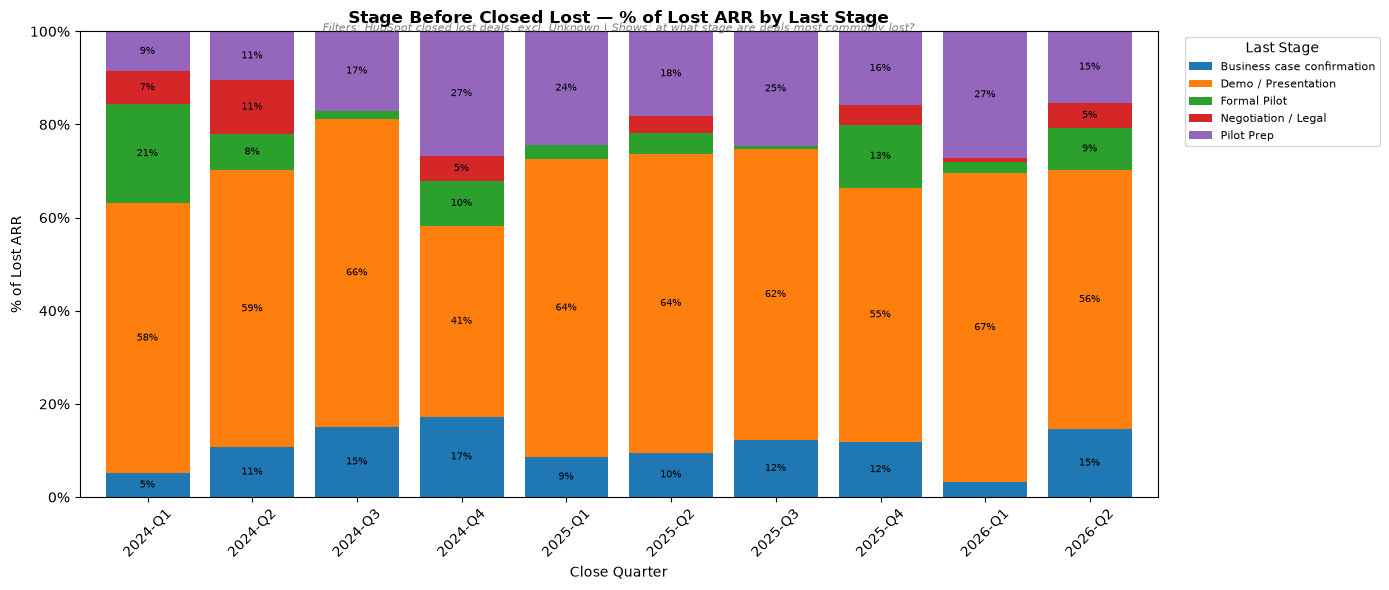

In [81]:
df18 = chart18_data[chart18_data['last_stage'] != 'Unknown'].copy()
quarter_order = sorted(df18['close_quarter'].unique())

pivot18 = df18.pivot_table(index='close_quarter', columns='last_stage', values='lost_arr', aggfunc='sum', fill_value=0)
pivot18 = pivot18.reindex(quarter_order).fillna(0)
pct18 = pivot18.div(pivot18.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct18.plot(kind='bar', stacked=True, ax=ax, width=0.8)
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=7)

ax.set_title('Stage Before Closed Lost — % of Lost ARR by Last Stage', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: HubSpot closed lost deals, excl. Unknown | Shows: at what stage are deals most commonly lost?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('Close Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Last Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Loss Rate — % of Lost ARR out of All Closed ARR (New Business)

Overall loss rate trended by quarter. Includes both won and lost deals in the denominator.

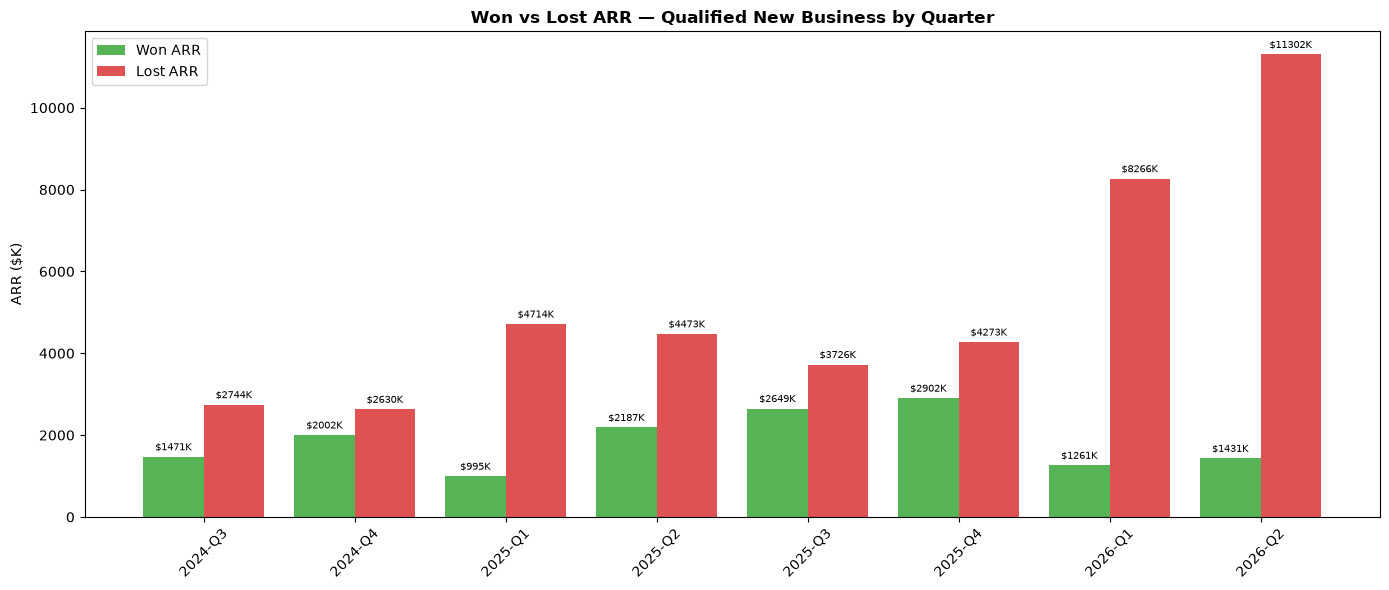

In [82]:
loss_rate_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    SUM(d.DEAL_NET_NEW_ARR) AS total_closed_arr,
    SUM(CASE WHEN d.IS_WON = FALSE THEN d.DEAL_NET_NEW_ARR ELSE 0 END) AS lost_arr,
    SUM(CASE WHEN d.IS_WON = TRUE THEN d.DEAL_NET_NEW_ARR ELSE 0 END) AS won_arr,
    ROUND(100.0 * SUM(CASE WHEN d.IS_WON = FALSE THEN d.DEAL_NET_NEW_ARR ELSE 0 END)
        / NULLIF(SUM(d.DEAL_NET_NEW_ARR), 0), 1) AS loss_rate_pct
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2
ORDER BY quarter_sort
""")

df_lr = loss_rate_data.sort_values('QUARTER_SORT')
df_lr['WON_ARR'] = pd.to_numeric(df_lr['WON_ARR'], errors='coerce').fillna(0) / 1000
df_lr['LOST_ARR'] = pd.to_numeric(df_lr['LOST_ARR'], errors='coerce').fillna(0) / 1000

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(df_lr))
width = 0.4
bars_won = ax.bar([i - width/2 for i in x], df_lr['WON_ARR'], width, label='Won ARR', color='tab:green', alpha=0.8)
bars_lost = ax.bar([i + width/2 for i in x], df_lr['LOST_ARR'], width, label='Lost ARR', color='tab:red', alpha=0.8)

ax.bar_label(bars_won, labels=[f'${v:.0f}K' for v in df_lr['WON_ARR']], fontsize=7, padding=3)
ax.bar_label(bars_lost, labels=[f'${v:.0f}K' for v in df_lr['LOST_ARR']], fontsize=7, padding=3)

ax.set_xticks(x)
ax.set_xticklabels(df_lr['CLOSE_QUARTER'], rotation=45)
ax.set_title('Won vs Lost ARR — Qualified New Business by Quarter', fontsize=12, fontweight='bold')
ax.set_ylabel('ARR ($K)')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

In [83]:
# ============================================================
# Gap analysis: HubSpot CSV vs FACT_DEALS
# ============================================================
import pandas as pd

csv_path = '/Users/guyamitai/Downloads/hubspot-crm-exports-my-deals-2026-07-07-1.csv'
csv_df = pd.read_csv(csv_path, dtype={'Record ID': str})
csv_df['Record ID'] = csv_df['Record ID'].str.strip()
csv_df['Close Date'] = pd.to_datetime(csv_df['Close Date'], format='mixed', errors='coerce')
csv_df['Amount'] = pd.to_numeric(csv_df['Amount'], errors='coerce')

# Filter CSV same as SF: pipeline=Classic, type=newbusiness, closed, close_date < today
csv_df = csv_df[
    (csv_df['Pipeline'] == 'Classic') &
    (csv_df['Deal Type'] == 'New Business') &
    (csv_df['Is Deal Closed?'] == True) &
    (csv_df['Close Date'] < pd.Timestamp.now())
].reset_index(drop=True)

print(f"CSV deals after filter: {len(csv_df)}")

# Get all matching deals from Snowflake
sf_df = run_query("""
SELECT 
    d.DEAL_CRM_ID::VARCHAR AS DEAL_ID,
    d.DEAL_NAME,
    d.DEAL_STAGE,
    d.DEAL_CLOSED_DATE,
    d.DEAL_TOTAL_ARR,
    d.DEAL_NET_NEW_ARR,
    e.DISPLAY_NAME AS OWNER_NAME
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_EMPLOYEE e ON d.SK_SALES_OWNER = e.SK_EMPLOYEE
WHERE d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.IS_CLOSED = TRUE
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.DEAL_CLOSED_DATE < CURRENT_DATE()
  AND COALESCE(c.COMPANY_NAME, '') NOT ILIKE '%%test%%'
  AND COALESCE(c.COMPANY_NAME, '') != 'Port'
""")
sf_df['DEAL_ID'] = sf_df['DEAL_ID'].astype(str).str.strip()
sf_df['DEAL_TOTAL_ARR'] = pd.to_numeric(sf_df['DEAL_TOTAL_ARR'], errors='coerce')
sf_df['DEAL_CLOSED_DATE'] = pd.to_datetime(sf_df['DEAL_CLOSED_DATE'], errors='coerce')

print(f"Snowflake deals: {len(sf_df)}")

# Merge on Record ID / DEAL_CRM_ID
merged = csv_df.merge(sf_df, left_on='Record ID', right_on='DEAL_ID', how='outer', indicator=True)

# 1. Deals in CSV but NOT in Snowflake
csv_only = merged[merged['_merge'] == 'left_only'][['Record ID', 'Deal Name', 'Deal Stage', 'Close Date', 'Amount', 'Deal owner']].copy()
print(f"\n--- IN CSV, NOT IN SNOWFLAKE: {len(csv_only)} deals ---")
if len(csv_only) > 0:
    print(csv_only.to_string(index=False))

# 2. Deals in both - check close date mismatch (>1 day diff)
both = merged[merged['_merge'] == 'both'].copy()
both['close_date_diff'] = (both['Close Date'] - both['DEAL_CLOSED_DATE']).dt.days
date_mismatches = both[both['close_date_diff'].abs() > 1][['Record ID', 'Deal Name', 'Close Date', 'DEAL_CLOSED_DATE', 'close_date_diff']].copy()
print(f"\n--- CLOSE DATE MISMATCHES (>1 day): {len(date_mismatches)} deals ---")
if len(date_mismatches) > 0:
    display(date_mismatches.sort_values('close_date_diff', key=abs, ascending=False).head(20))

# 3. ARR mismatches (>$100 difference)
both['arr_diff'] = both['Amount'] - both['DEAL_TOTAL_ARR']
arr_mismatches = both[both['arr_diff'].abs() > 100][['Record ID', 'Deal Name', 'Amount', 'DEAL_TOTAL_ARR', 'arr_diff']].copy()
print(f"\n--- ARR MISMATCHES (>$100): {len(arr_mismatches)} deals, total gap: ${arr_mismatches['arr_diff'].sum():,.0f} ---")
if len(arr_mismatches) > 0:
    display(arr_mismatches.sort_values('arr_diff', key=abs, ascending=False).head(20))

# 4. Owner mismatches
both['csv_owner_clean'] = both['Deal owner'].str.replace(r'\s*\(Deactivated User\)', '', regex=True).str.strip()
both['sf_owner_clean'] = both['OWNER_NAME'].str.strip()
owner_mismatches = both[both['csv_owner_clean'] != both['sf_owner_clean']][['Record ID', 'Deal Name', 'csv_owner_clean', 'sf_owner_clean']].copy()
print(f"\n--- OWNER MISMATCHES: {len(owner_mismatches)} deals ---")
if len(owner_mismatches) > 0:
    display(owner_mismatches.head(20))

CSV deals after filter: 827
Snowflake deals: 2933

--- IN CSV, NOT IN SNOWFLAKE: 0 deals ---

--- CLOSE DATE MISMATCHES (>1 day): 0 deals ---

--- ARR MISMATCHES (>$100): 8 deals, total gap: $420,000 ---


,Record ID,Deal Name,Amount,DEAL_TOTAL_ARR,arr_diff
2435,55927357232,Société Générale,250000.0,0.0,250000.0
2896,61085526439,Booking.com - Backstage Replacement - 6k Users,200000.0,0.0,200000.0
2397,54218149647,Nordea - ICBT AEP - New Business,100000.0,0.0,100000.0
2790,59638544392,ATOS - Greenfield IDP (New Business),100000.0,0.0,100000.0
384,15968158526,Expedia,72000.0,144000.0,-72000.0
1329,32736391094,APNIC,72000.0,144000.0,-72000.0
2223,48798856468,Sagent - 2026,50000.0,100000.0,-50000.0
2157,46256776210,Minted,36000.0,72000.0,-36000.0



--- OWNER MISMATCHES: 29 deals ---


,Record ID,Deal Name,csv_owner_clean,sf_owner_clean
688,19002272439,TownSq,Joe Leland,Joseph(Joe) Leland
717,19488711193,Accolade Inc,Joe Leland,Joseph(Joe) Leland
722,19522131763,Hurb,Joe Leland,Joseph(Joe) Leland
774,20299244883,Conta Azul,Joe Leland,Joseph(Joe) Leland
787,20480968848,ISS STOXX,Joe Leland,Joseph(Joe) Leland
831,21094928925,Mosaic,Joe Leland,Joseph(Joe) Leland
885,22069485136,MuniBilling,Joe Leland,Joseph(Joe) Leland
947,23252143465,Venturus,Joe Leland,Joseph(Joe) Leland
1082,29485575794,EMBURSE,Joe Leland,Joseph(Joe) Leland
1126,29824346776,OneTrust,Joe Leland,Joseph(Joe) Leland


In [84]:
# Check the 4 mismatched deals: Amount vs DEAL_TOTAL_ARR vs DEAL_NET_NEW_ARR
check_ids = ['15968158526', '32736391094', '48798856468', '46256776210']
check_df = run_query(f"""
SELECT DEAL_CRM_ID::VARCHAR AS DEAL_ID, DEAL_NAME, DEAL_TOTAL_ARR, DEAL_NET_NEW_ARR
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS
WHERE DEAL_CRM_ID IN ({','.join(check_ids)})
""")
csv_subset = csv_df[csv_df['Record ID'].isin(check_ids)][['Record ID','Deal Name','Amount']].copy()
comparison = csv_subset.merge(check_df, left_on='Record ID', right_on='DEAL_ID')
comparison[['Deal Name','Amount','DEAL_TOTAL_ARR','DEAL_NET_NEW_ARR']]

,Deal Name,Amount,DEAL_TOTAL_ARR,DEAL_NET_NEW_ARR
0,APNIC,72000.0,144000.0,72000.0
1,Expedia,72000.0,144000.0,72000.0
2,Minted,36000.0,72000.0,36000.0
3,Sagent - 2026,50000.0,100000.0,50000.0


In [85]:
# Generate SQL VALUES clause from CSV for untitled.sql
rows = []
for _, r in csv_df.iterrows():
    rid = r['Record ID']
    amt = r['Amount'] if pd.notna(r['Amount']) else 0
    cd = r['Close Date'].strftime('%Y-%m-%d') if pd.notna(r['Close Date']) else '1900-01-01'
    owner = str(r.get('Deal owner', '')).replace("'", "''")
    rows.append(f"    ('{rid}', {amt:.0f}, '{cd}', '{owner}')")

values_sql = ',\n'.join(rows)
sql = f"""WITH csv_deals AS (
    SELECT $1 AS deal_id, $2::NUMBER AS csv_amount, $3::DATE AS csv_close_date, $4 AS csv_owner
    FROM VALUES
{values_sql}
)
SELECT
    c.deal_id,
    f.DEAL_NAME,
    c.csv_amount,
    f.DEAL_NET_NEW_ARR AS sf_arr,
    c.csv_amount - f.DEAL_NET_NEW_ARR AS arr_diff,
    c.csv_close_date,
    f.DEAL_CLOSED_DATE AS sf_close_date,
    DATEDIFF('day', f.DEAL_CLOSED_DATE, c.csv_close_date) AS close_date_diff_days,
    c.csv_owner,
    e.DISPLAY_NAME AS sf_owner
FROM csv_deals c
LEFT JOIN PORT_ANALYTICS_PROD.DWH.FACT_DEALS f
    ON c.deal_id = f.DEAL_CRM_ID::VARCHAR
    AND f.PIPELINE = 'Classic'
    AND f.DEAL_TYPE = 'newbusiness'
    AND f.IS_CLOSED = TRUE
    AND f.ARCHIVED = FALSE
    AND f._DELETED_TIMESTAMP IS NULL
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_EMPLOYEE e ON f.SK_SALES_OWNER = e.SK_EMPLOYEE
WHERE (c.csv_amount - f.DEAL_NET_NEW_ARR != 0)
   OR (ABS(DATEDIFF('day', f.DEAL_CLOSED_DATE, c.csv_close_date)) > 1)
ORDER BY ABS(c.csv_amount - COALESCE(f.DEAL_NET_NEW_ARR, 0)) DESC;
"""

print(f"Generated SQL with {len(rows)} rows in VALUES clause")
print(f"SQL length: {len(sql):,} chars")

Generated SQL with 827 rows in VALUES clause
SQL length: 54,503 chars


In [86]:
# Write the SQL to untitled.sql
with open('/Users/guyamitai/Documents/Snow/snowflake-guy/streamlit-apps/untitled.sql', 'w') as f:
    f.write(sql)
print("Written to untitled.sql")

Written to untitled.sql


In [87]:
results = run_query(sql)
print(f"{len(results)} mismatched deals found")
if len(results) > 0:
    display(results)

6 mismatched deals found


,DEAL_ID,DEAL_NAME,CSV_AMOUNT,SF_ARR,ARR_DIFF,CSV_CLOSE_DATE,SF_CLOSE_DATE,CLOSE_DATE_DIFF_DAYS,CSV_OWNER,SF_OWNER
0,55927357232,Société Générale,250000,0.0,250000.0,2026-04-15,2026-04-15,0,John Barnes,John Barnes
1,61085526439,Booking.com - Backstage Replacement - 6k Users,200000,0.0,200000.0,2026-06-11,2026-06-11,0,John Barnes,John Barnes
2,54218149647,Nordea - ICBT AEP - New Business,100000,0.0,100000.0,2026-05-06,2026-05-06,0,John Barnes,John Barnes
3,59638544392,ATOS - Greenfield IDP (New Business),100000,0.0,100000.0,2026-05-06,2026-05-06,0,John Barnes,John Barnes
4,34627684968,BCP,333048,333047.7,0.3,2024-12-20,2024-12-20,0,Sam Neill (Deactivated User),Sam Neill
5,35121402689,Air New Zealand,89201,89200.8,0.2,2026-02-26,2026-02-26,0,Scott Dunion,Scott Dunion


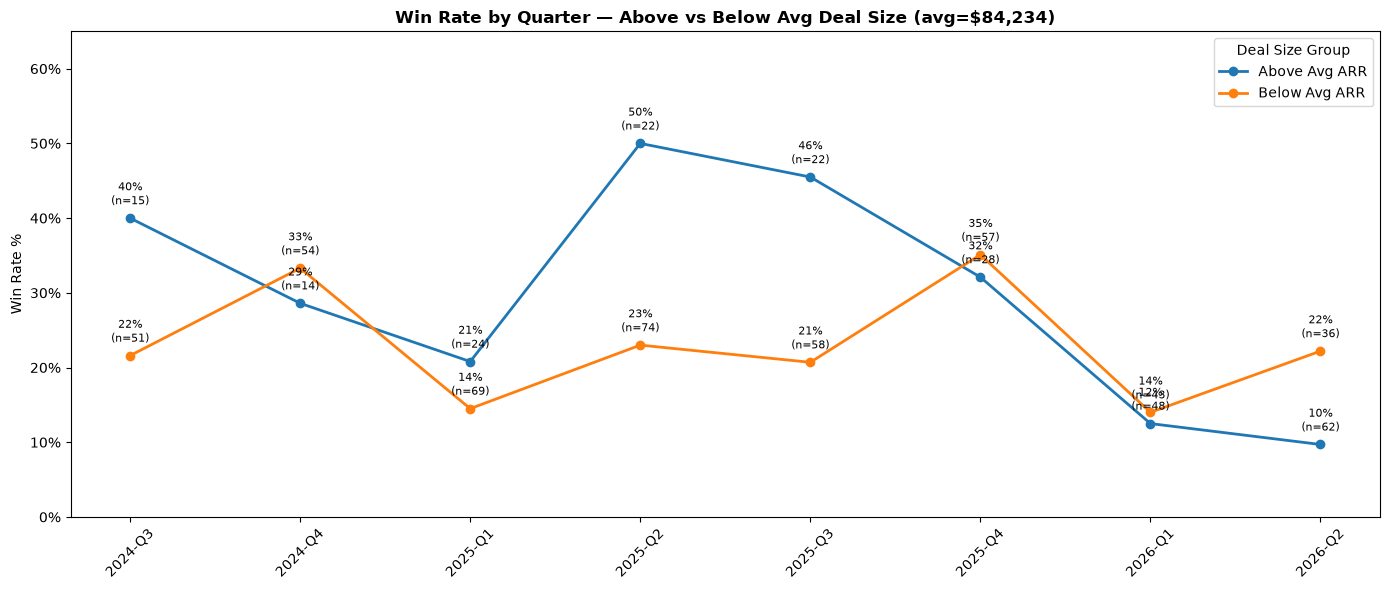

In [88]:
win_rate_by_size = run_query(f"""
WITH avg_arr AS (
    SELECT AVG(d.DEAL_NET_NEW_ARR) AS overall_avg
    FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
    WHERE d.PIPELINE = 'Classic'
      AND d.DEAL_TYPE = 'newbusiness'
      AND d.ARCHIVED = FALSE
      AND d._DELETED_TIMESTAMP IS NULL
      AND d.IS_CLOSED = TRUE
      AND d.QUALIFIED_DATE IS NOT NULL
      AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
      AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
)
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    CASE WHEN d.DEAL_NET_NEW_ARR >= a.overall_avg THEN 'Above Avg ARR' ELSE 'Below Avg ARR' END AS deal_size_group,
    COUNT(*) AS total_deals,
    SUM(CASE WHEN d.IS_WON = TRUE THEN 1 ELSE 0 END) AS won_deals,
    ROUND(100.0 * SUM(CASE WHEN d.IS_WON = TRUE THEN 1 ELSE 0 END) / COUNT(*), 1) AS win_rate_pct
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
CROSS JOIN avg_arr a
WHERE d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.QUALIFIED_DATE IS NOT NULL
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, deal_size_group
""")

avg_val = run_query(f"""
SELECT ROUND(AVG(d.DEAL_NET_NEW_ARR), 0) AS overall_avg
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.PIPELINE = 'Classic' AND d.DEAL_TYPE = 'newbusiness' AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL AND d.IS_CLOSED = TRUE AND d.QUALIFIED_DATE IS NOT NULL
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
""")
avg_amount = float(avg_val['OVERALL_AVG'].iloc[0])

df_wr = win_rate_by_size.copy()
df_wr['WIN_RATE_PCT'] = pd.to_numeric(df_wr['WIN_RATE_PCT'], errors='coerce')
quarter_order = df_wr.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

fig, ax = plt.subplots(figsize=(14, 6))
for group, gdf in df_wr.groupby('DEAL_SIZE_GROUP'):
    gdf = gdf.set_index('CLOSE_QUARTER').reindex(quarter_order)
    ax.plot(quarter_order, gdf['WIN_RATE_PCT'], marker='o', linewidth=2, label=group)
    for x, y, n in zip(quarter_order, gdf['WIN_RATE_PCT'], gdf['TOTAL_DEALS']):
        if pd.notna(y):
            ax.annotate(f'{y:.0f}%\n(n={int(n)})', (x, y), textcoords="offset points",
                        xytext=(0, 10), fontsize=8, ha='center')

ax.set_title(f'Win Rate by Quarter — Above vs Below Avg Deal Size (avg=${avg_amount:,.0f})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Win Rate %')
ax.set_xlabel('')
ax.legend(title='Deal Size Group')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(df_wr['WIN_RATE_PCT'].max() * 1.3, 50))
plt.tight_layout()
plt.show()

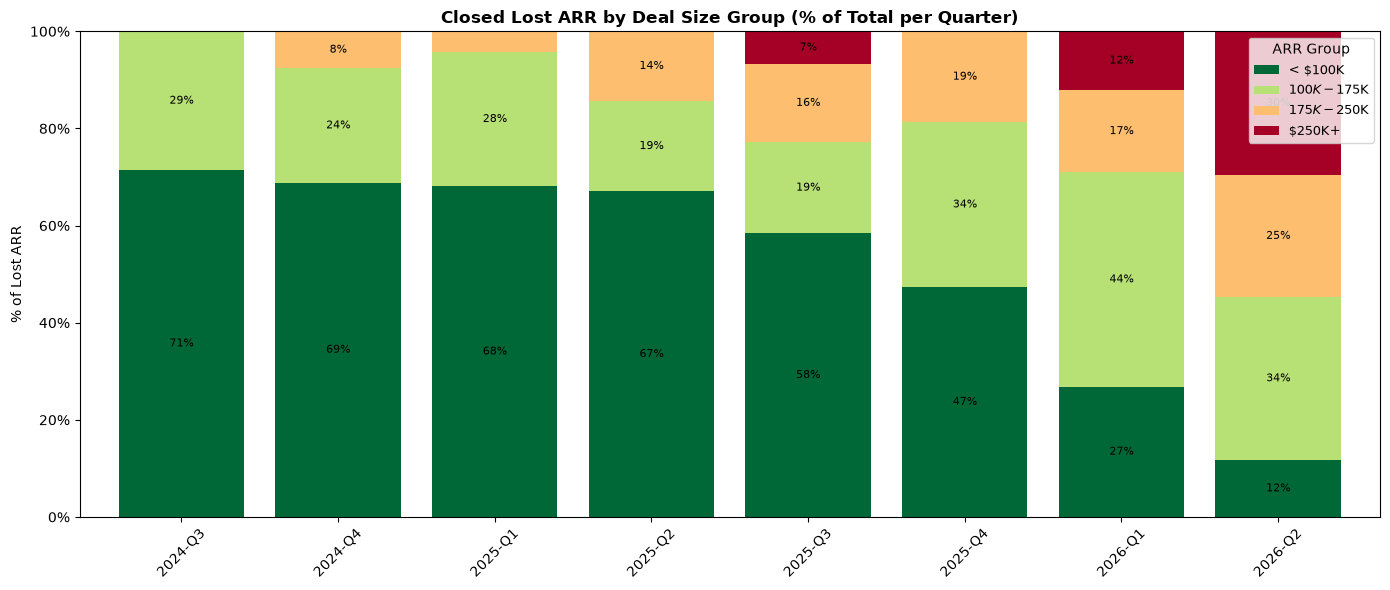

In [89]:
arr_group_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    CASE
        WHEN d.DEAL_NET_NEW_ARR < 100000 THEN '< $100K'
        WHEN d.DEAL_NET_NEW_ARR < 175000 THEN '$100K-$175K'
        WHEN d.DEAL_NET_NEW_ARR < 250000 THEN '$175K-$250K'
        ELSE '$250K+'
    END AS arr_group,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, arr_group
""")

df_ag = arr_group_data.copy()
df_ag['LOST_ARR'] = pd.to_numeric(df_ag['LOST_ARR'], errors='coerce').fillna(0)
quarter_order = df_ag.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

pivot = df_ag.pivot_table(index='CLOSE_QUARTER', columns='ARR_GROUP', values='LOST_ARR', aggfunc='sum', fill_value=0)
col_order = ['< $100K', '$100K-$175K', '$175K-$250K', '$250K+']
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns]).reindex(quarter_order).fillna(0)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct.plot(kind='bar', stacked=True, ax=ax, width=0.8, colormap='RdYlGn_r')
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Closed Lost ARR by Deal Size Group (% of Total per Quarter)', fontsize=12, fontweight='bold')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='ARR Group', loc='upper right', fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

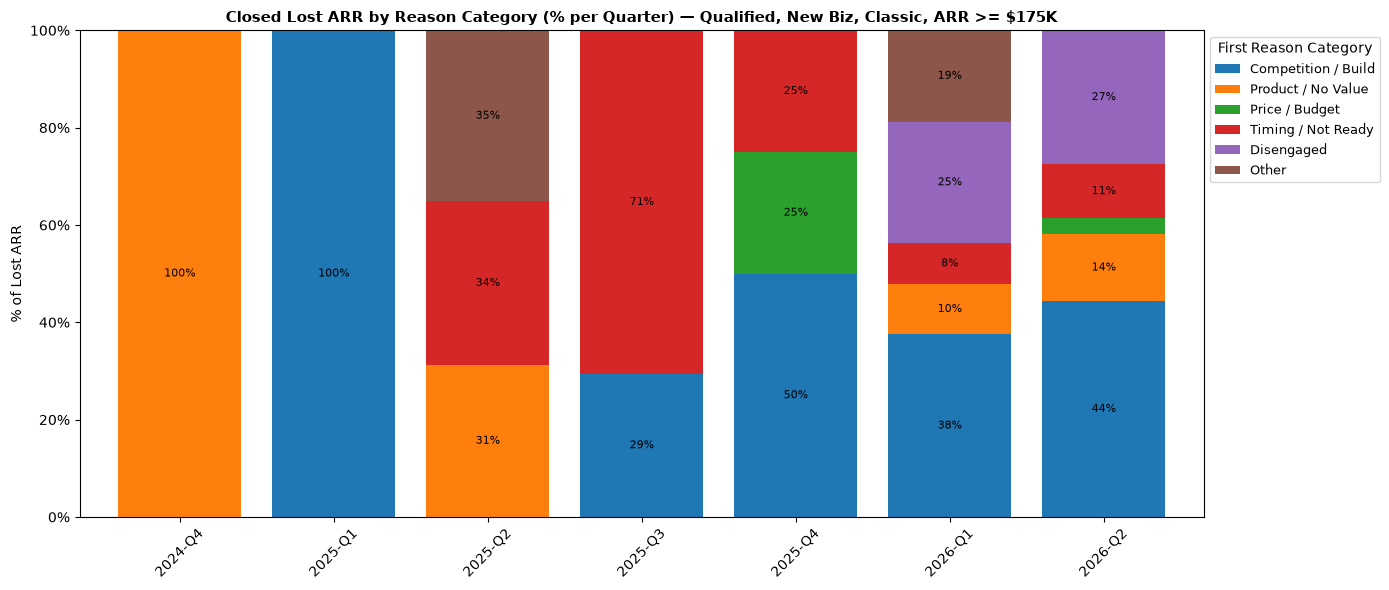

In [90]:
loss_reason_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    d.CLOSED_LOST_REASON AS raw_reason,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND d.DEAL_NET_NEW_ARR >= 175000
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, raw_reason
""")

# Categorize using keyword matching across entire string
def categorize_reason(r):
    if pd.isna(r) or r is None or r.strip() == '':
        return 'Unknown'
    r = r.lower()
    if 'competition' in r or 'internal build' in r:
        return 'Competition / Build'
    if 'product' in r or 'no value' in r:
        return 'Product / No Value'
    if 'price' in r or 'budget' in r:
        return 'Price / Budget'
    if 'bad timing' in r or 'early stage' in r:
        return 'Timing / Not Ready'
    if 'champion' in r or 'company cuts' in r:
        return 'Champion Left / Cuts'
    if 'unable to connect' in r or 'no_show' in r:
        return 'Disengaged'
    return 'Other'

df_lr = loss_reason_data.copy()
df_lr['LOST_ARR'] = pd.to_numeric(df_lr['LOST_ARR'], errors='coerce').fillna(0)
df_lr['reason_category'] = df_lr['RAW_REASON'].apply(categorize_reason)

# Re-aggregate by category
df_lr = df_lr.groupby(['CLOSE_QUARTER', 'QUARTER_SORT', 'reason_category'], as_index=False)['LOST_ARR'].sum()
quarter_order = df_lr.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

pivot = df_lr.pivot_table(index='CLOSE_QUARTER', columns='reason_category', values='LOST_ARR', aggfunc='sum', fill_value=0)
col_order = ['Competition / Build', 'Product / No Value', 'Price / Budget', 'Timing / Not Ready', 'Champion Left / Cuts', 'Disengaged', 'Other', 'Unknown']
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns]).reindex(quarter_order).fillna(0)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct.plot(kind='bar', stacked=True, ax=ax, width=0.8)
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Closed Lost ARR by Reason Category (% per Quarter) — Qualified, New Biz, Classic, ARR >= $175K', fontsize=11, fontweight='bold')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='First Reason Category', loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

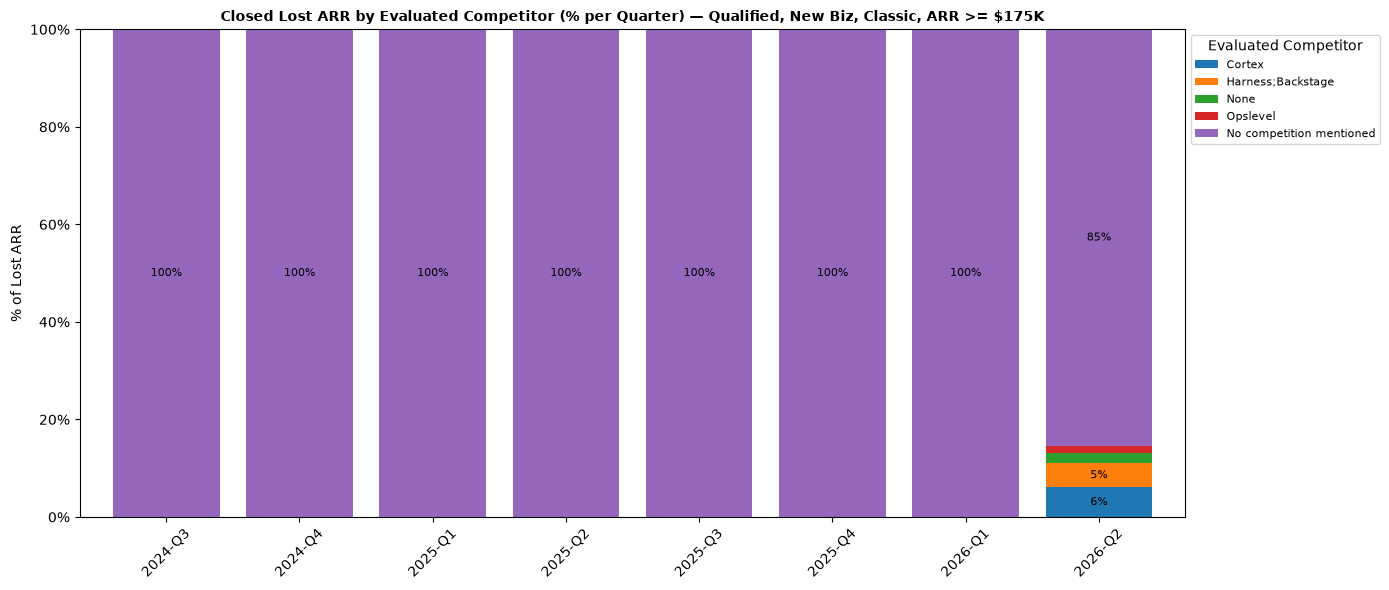

In [91]:
competitor_data = run_query(f"""
WITH latest_competitor AS (
    SELECT h.DEALID, h.VALUE AS competitor
    FROM RAW_PORT_EXTERNAL.AB_HUBSPOT_HISTORY.DEALS_PROPERTY_HISTORY h
    WHERE h.PROPERTY = 'evaluated_competitors'
      AND h.VALUE IS NOT NULL
      AND TRIM(h.VALUE) != ''
    QUALIFY ROW_NUMBER() OVER (PARTITION BY h.DEALID ORDER BY h.TIMESTAMP DESC) = 1
)
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    COALESCE(NULLIF(TRIM(lc.competitor), ''), 'No competition mentioned') AS competitor,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN latest_competitor lc ON d.DEAL_CRM_ID = lc.DEALID
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND d.DEAL_NET_NEW_ARR >= 100000
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, competitor
""")

df_comp = competitor_data.copy()
df_comp['LOST_ARR'] = pd.to_numeric(df_comp['LOST_ARR'], errors='coerce').fillna(0)
quarter_order = df_comp.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

pivot = df_comp.pivot_table(index='CLOSE_QUARTER', columns='COMPETITOR', values='LOST_ARR', aggfunc='sum', fill_value=0)
pivot = pivot.reindex(quarter_order).fillna(0)

# Sort columns: 'No competition mentioned' last, others by total ARR descending
cols_sorted = pivot.drop(columns='No competition mentioned', errors='ignore').sum().sort_values(ascending=False).index.tolist()
if 'No competition mentioned' in pivot.columns:
    cols_sorted.append('No competition mentioned')
pivot = pivot[cols_sorted]

pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct.plot(kind='bar', stacked=True, ax=ax, width=0.8)
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Closed Lost ARR by Evaluated Competitor (% per Quarter) — Qualified, New Biz, Classic, ARR >= $175K', fontsize=10, fontweight='bold')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Evaluated Competitor', loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

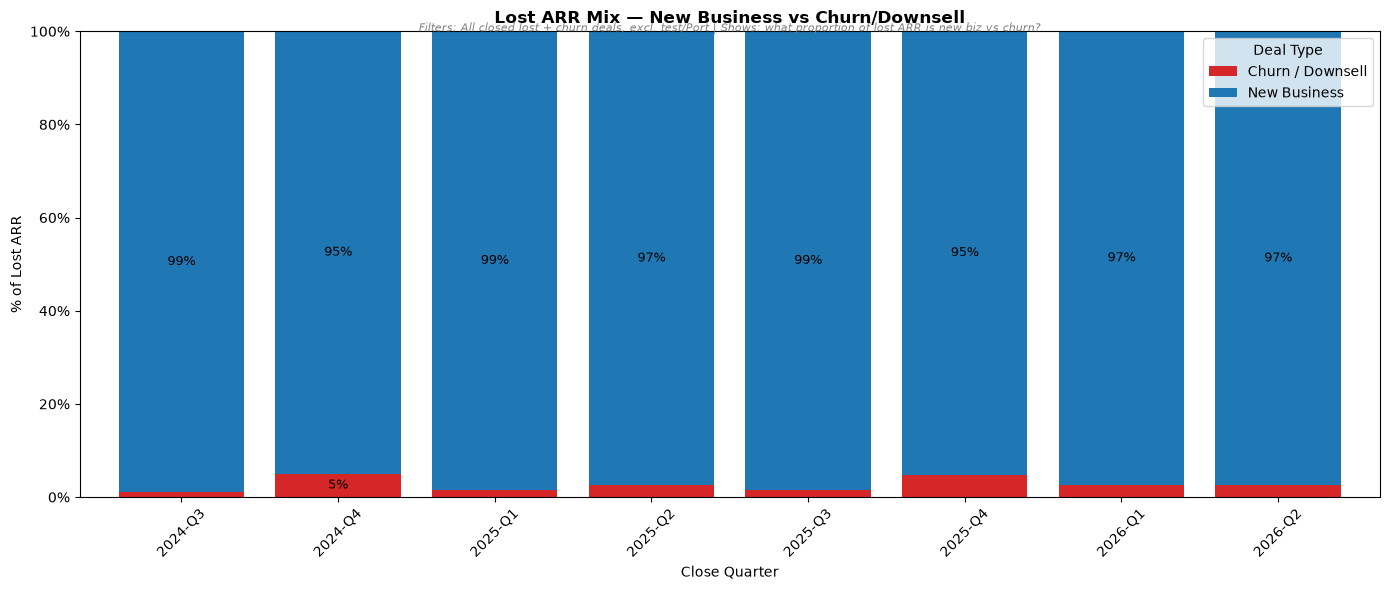

In [92]:
# Chart: Lost ARR by Deal Type — New Business vs Churn/Downsell
chart_type_data = run_query(f"""
SELECT
    CONCAT(YEAR(d.DEAL_CLOSED_DATE), '-Q', QUARTER(d.DEAL_CLOSED_DATE)) AS close_quarter,
    DATE_TRUNC('quarter', d.DEAL_CLOSED_DATE) AS quarter_sort,
    CASE
        WHEN d.DEAL_TYPE = 'newbusiness' THEN 'New Business'
        WHEN d.DEAL_STAGE = 'Churn' THEN 'Churn / Downsell'
        ELSE 'Other'
    END AS deal_type_group,
    SUM(ABS(d.DEAL_NET_NEW_ARR)) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
WHERE d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.DEAL_CLOSED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND d.DEAL_CLOSED_DATE <= '2026-06-30'
  AND (d.DEAL_TYPE = 'newbusiness' OR d.DEAL_STAGE = 'Churn')
  AND COALESCE(c.COMPANY_NAME, '') NOT ILIKE '%test%'
  AND COALESCE(c.COMPANY_NAME, '') != 'Port'
GROUP BY 1, 2, 3
""")

df_type = chart_type_data.copy()
df_type['LOST_ARR'] = pd.to_numeric(df_type['LOST_ARR'], errors='coerce').fillna(0)
quarter_order = df_type.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

pivot_type = df_type.pivot_table(index='CLOSE_QUARTER', columns='DEAL_TYPE_GROUP', values='LOST_ARR', aggfunc='sum', fill_value=0)
pivot_type = pivot_type.reindex(quarter_order).fillna(0)
pct_type = pivot_type.div(pivot_type.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct_type.plot(kind='bar', stacked=True, ax=ax, width=0.8, color={'New Business': 'tab:blue', 'Churn / Downsell': 'tab:red'})
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

ax.set_title('Lost ARR Mix — New Business vs Churn/Downsell', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: All closed lost + churn deals, excl. test/Port | Shows: what proportion of lost ARR is new biz vs churn?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('Close Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Deal Type')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

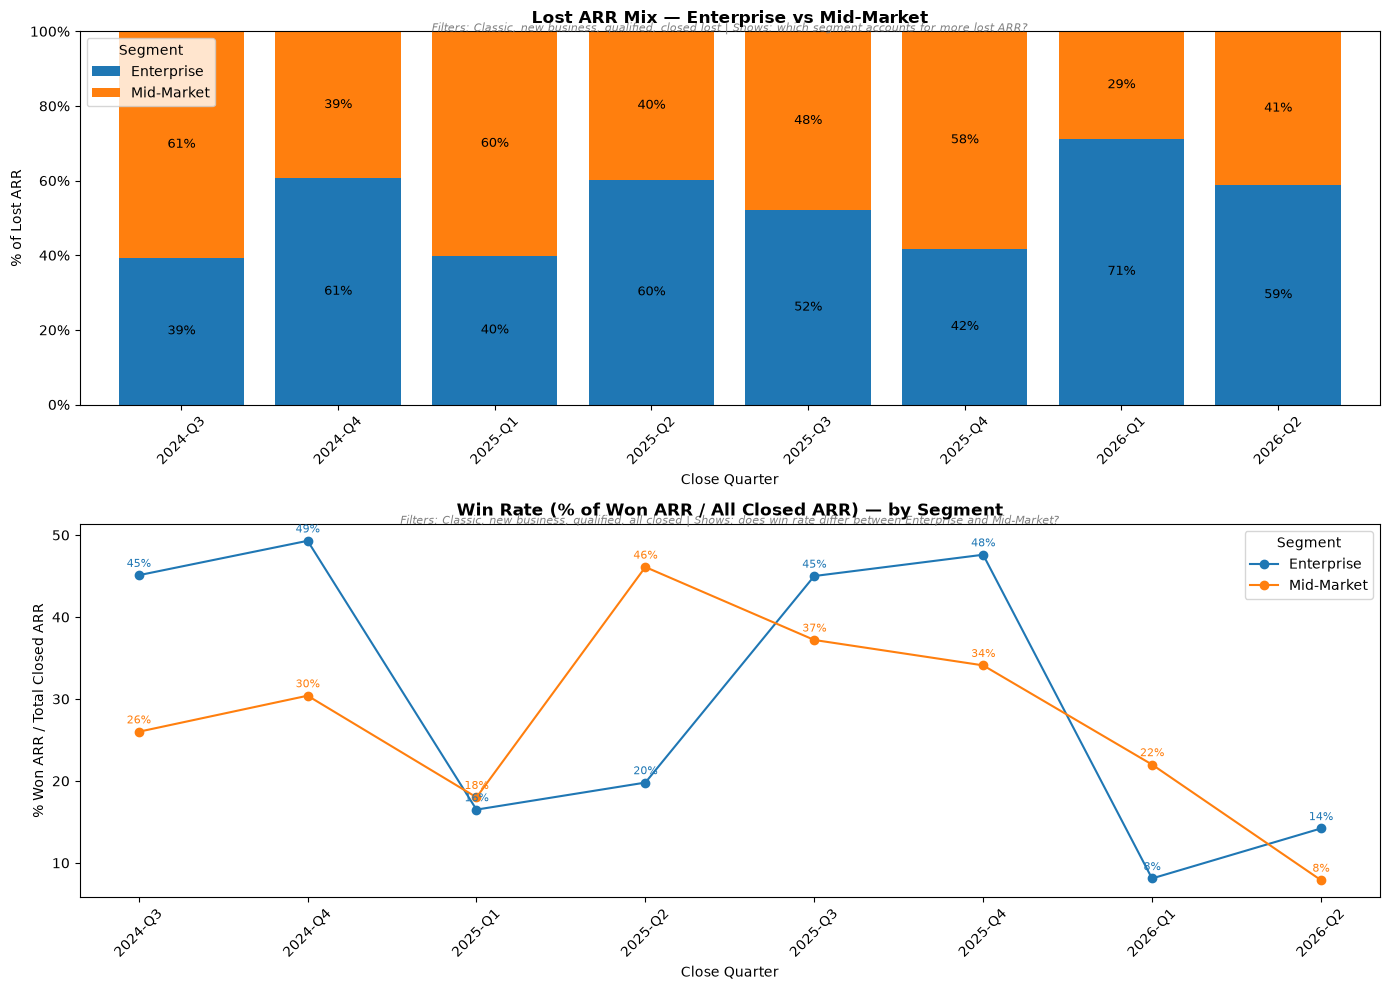

In [93]:
# Chart: Lost ARR & Win Rate by Segment (Enterprise vs Mid-Market)
segment_data = run_query(f"""
WITH base AS (
    SELECT
        CONCAT(YEAR(d.DEAL_CLOSED_DATE), '-Q', QUARTER(d.DEAL_CLOSED_DATE)) AS close_quarter,
        DATE_TRUNC('quarter', d.DEAL_CLOSED_DATE) AS quarter_sort,
        CASE
            WHEN d.DEAL_TEAM_NAME ILIKE '%Ent%' THEN 'Enterprise'
            WHEN d.DEAL_TEAM_NAME ILIKE '%MM%' THEN 'Mid-Market'
            ELSE COALESCE(c.SEGMENT, 'Unknown')
        END AS segment,
        d.IS_WON,
        d.DEAL_NET_NEW_ARR
    FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
    LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
    WHERE d.IS_CLOSED = TRUE
      AND d.QUALIFIED_DATE IS NOT NULL
      AND d.PIPELINE = 'Classic'
      AND d.DEAL_TYPE = 'newbusiness'
      AND d.ARCHIVED = FALSE
      AND d._DELETED_TIMESTAMP IS NULL
      AND d.DEAL_NET_NEW_ARR > 0
      AND d.DEAL_CLOSED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
      AND d.DEAL_CLOSED_DATE <= '2026-06-30'
      AND COALESCE(c.COMPANY_NAME, '') NOT ILIKE '%test%'
      AND COALESCE(c.COMPANY_NAME, '') != 'Port'
)
SELECT
    close_quarter,
    quarter_sort,
    segment,
    SUM(CASE WHEN IS_WON = FALSE THEN ABS(DEAL_NET_NEW_ARR) ELSE 0 END) AS lost_arr,
    SUM(CASE WHEN IS_WON = TRUE THEN DEAL_NET_NEW_ARR ELSE 0 END) AS won_arr,
    SUM(ABS(DEAL_NET_NEW_ARR)) AS total_arr
FROM base
WHERE segment IN ('Enterprise', 'Mid-Market')
GROUP BY 1, 2, 3
""")

df_seg = segment_data.copy()
df_seg['LOST_ARR'] = pd.to_numeric(df_seg['LOST_ARR'], errors='coerce').fillna(0)
df_seg['WON_ARR'] = pd.to_numeric(df_seg['WON_ARR'], errors='coerce').fillna(0)
df_seg['TOTAL_ARR'] = pd.to_numeric(df_seg['TOTAL_ARR'], errors='coerce').fillna(0)
quarter_order = df_seg.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

# --- Chart A: 100% stacked bar of lost ARR by segment ---
pivot_lost = df_seg.pivot_table(index='CLOSE_QUARTER', columns='SEGMENT', values='LOST_ARR', aggfunc='sum', fill_value=0)
pivot_lost = pivot_lost.reindex(quarter_order).fillna(0)
pct_lost = pivot_lost.div(pivot_lost.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]
pct_lost.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color={'Enterprise': 'tab:blue', 'Mid-Market': 'tab:orange'})
for container in ax1.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax1.bar_label(container, labels=labels, label_type='center', fontsize=9)
ax1.set_title('Lost ARR Mix — Enterprise vs Mid-Market', fontsize=12, fontweight='bold')
ax1.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost | Shows: which segment accounts for more lost ARR?', transform=ax1.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax1.set_ylabel('% of Lost ARR')
ax1.set_xlabel('Close Quarter')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(title='Segment')
ax1.tick_params(axis='x', rotation=45)

# --- Chart B: Win rate by segment ---
win_rate = df_seg.groupby(['CLOSE_QUARTER', 'SEGMENT']).agg(
    won=('WON_ARR', 'sum'), total=('TOTAL_ARR', 'sum')
).reset_index()
win_rate['win_rate'] = (100.0 * win_rate['won'] / win_rate['total']).round(1)

ax2 = axes[1]
for segment, color in [('Enterprise', 'tab:blue'), ('Mid-Market', 'tab:orange')]:
    subset = win_rate[win_rate['SEGMENT'] == segment].set_index('CLOSE_QUARTER').reindex(quarter_order)
    line, = ax2.plot(subset.index, subset['win_rate'], marker='o', label=segment, color=color)
    for x, y in zip(subset.index, subset['win_rate']):
        if pd.notna(y):
            ax2.annotate(f'{y:.0f}%', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=8, ha='center', color=line.get_color())
ax2.set_title('Win Rate (% of Won ARR / All Closed ARR) — by Segment', fontsize=12, fontweight='bold')
ax2.text(0.5, 1.0, 'Filters: Classic, new business, qualified, all closed | Shows: does win rate differ between Enterprise and Mid-Market?', transform=ax2.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax2.set_ylabel('% Won ARR / Total Closed ARR')
ax2.set_xlabel('Close Quarter')
ax2.legend(title='Segment')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

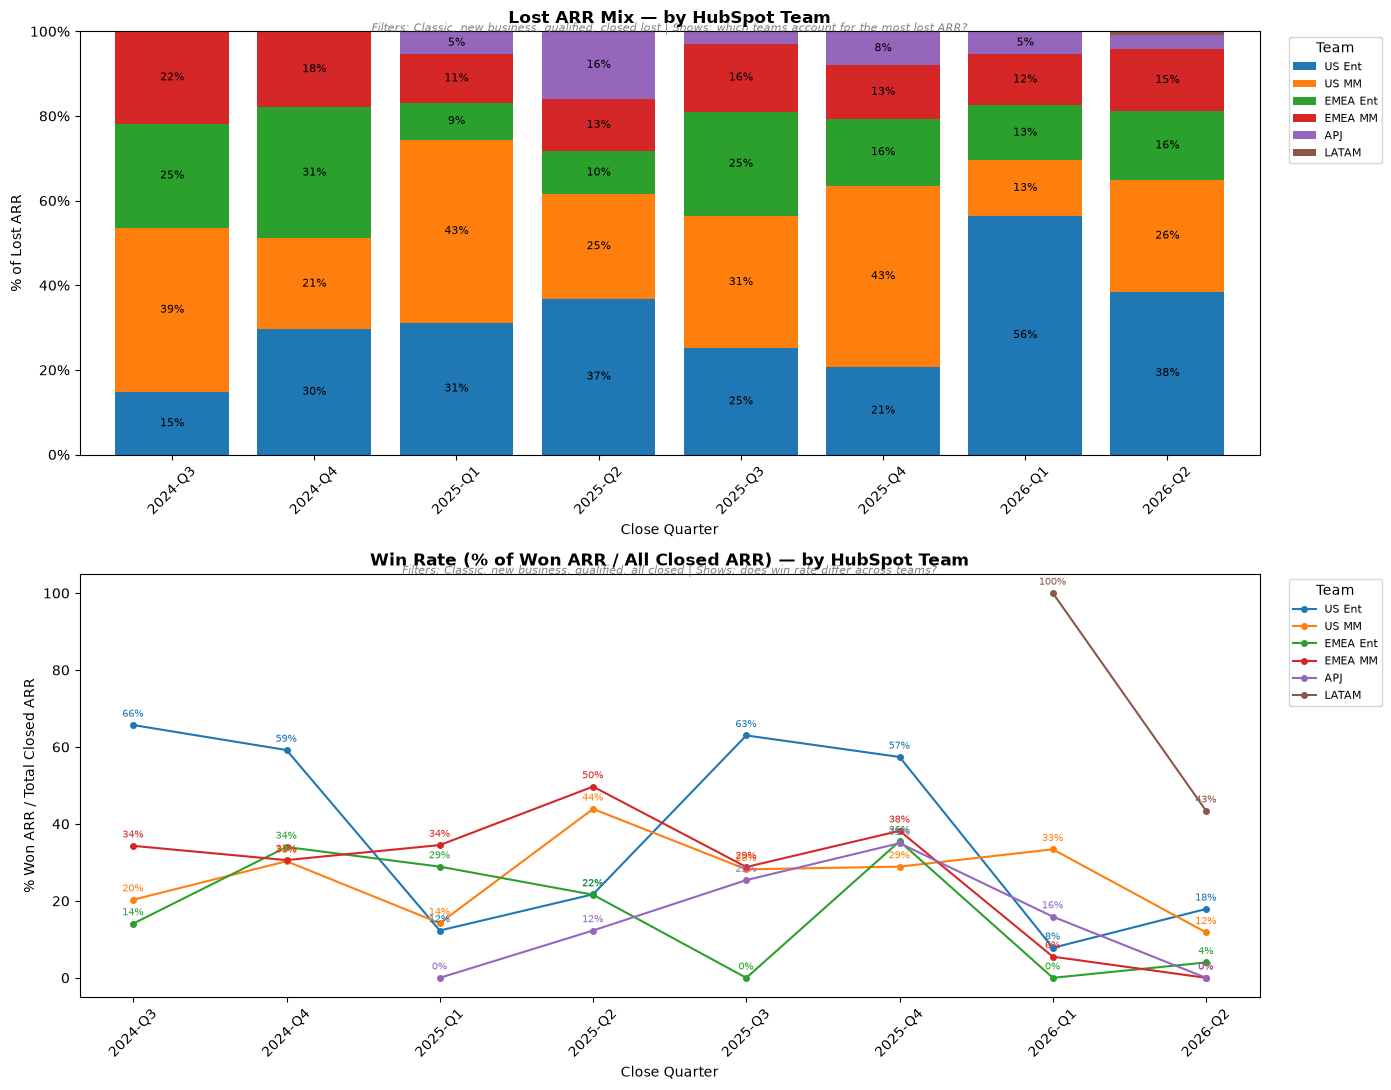

In [94]:
# Chart: Lost ARR & Win Rate by HubSpot Team
team_data = run_query(f"""
SELECT
    CONCAT(YEAR(d.DEAL_CLOSED_DATE), '-Q', QUARTER(d.DEAL_CLOSED_DATE)) AS close_quarter,
    DATE_TRUNC('quarter', d.DEAL_CLOSED_DATE) AS quarter_sort,
    COALESCE(d.DEAL_TEAM_NAME, 'Unknown') AS team,
    SUM(CASE WHEN d.IS_WON = FALSE THEN ABS(d.DEAL_NET_NEW_ARR) ELSE 0 END) AS lost_arr,
    SUM(CASE WHEN d.IS_WON = TRUE THEN d.DEAL_NET_NEW_ARR ELSE 0 END) AS won_arr,
    SUM(ABS(d.DEAL_NET_NEW_ARR)) AS total_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
WHERE d.IS_CLOSED = TRUE
  AND d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.DEAL_NET_NEW_ARR > 0
  AND d.DEAL_CLOSED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND d.DEAL_CLOSED_DATE <= '2026-06-30'
  AND d.DEAL_TEAM_NAME IS NOT NULL
  AND COALESCE(c.COMPANY_NAME, '') NOT ILIKE '%test%'
  AND COALESCE(c.COMPANY_NAME, '') != 'Port'
GROUP BY 1, 2, 3
""")

df_team = team_data.copy()
df_team['LOST_ARR'] = pd.to_numeric(df_team['LOST_ARR'], errors='coerce').fillna(0)
df_team['WON_ARR'] = pd.to_numeric(df_team['WON_ARR'], errors='coerce').fillna(0)
df_team['TOTAL_ARR'] = pd.to_numeric(df_team['TOTAL_ARR'], errors='coerce').fillna(0)
quarter_order = df_team.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

# Keep top teams by total lost ARR (drop the rest)
top_teams = df_team.groupby('TEAM')['LOST_ARR'].sum().nlargest(6).index.tolist()
df_team = df_team[df_team['TEAM'].isin(top_teams)].copy()
df_team['team_group'] = df_team['TEAM']

# Shared color map so both charts use the same color per team
team_colors = {team: plt.cm.tab10(i) for i, team in enumerate(top_teams)}

# --- Chart A: 100% stacked bar of lost ARR by team ---
pivot_lost = df_team.pivot_table(index='CLOSE_QUARTER', columns='team_group', values='LOST_ARR', aggfunc='sum', fill_value=0)
pivot_lost = pivot_lost.reindex(quarter_order).fillna(0)
pivot_lost = pivot_lost[top_teams]  # enforce consistent column/color order
pct_lost = pivot_lost.div(pivot_lost.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

ax1 = axes[0]
pct_lost.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color=[team_colors[t] for t in top_teams])
for container in ax1.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax1.bar_label(container, labels=labels, label_type='center', fontsize=8)
ax1.set_title('Lost ARR Mix — by HubSpot Team', fontsize=12, fontweight='bold')
ax1.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost | Shows: which teams account for the most lost ARR?', transform=ax1.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax1.set_ylabel('% of Lost ARR')
ax1.set_xlabel('Close Quarter')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(title='Team', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax1.tick_params(axis='x', rotation=45)

# --- Chart B: Win rate by team ---
win_rate = df_team.groupby(['CLOSE_QUARTER', 'team_group']).agg(
    won=('WON_ARR', 'sum'), total=('TOTAL_ARR', 'sum')
).reset_index()
win_rate['win_rate'] = (100.0 * win_rate['won'] / win_rate['total']).round(1)

ax2 = axes[1]
for team in top_teams:
    subset = win_rate[win_rate['team_group'] == team].set_index('CLOSE_QUARTER').reindex(quarter_order)
    if subset['win_rate'].notna().any():
        line, = ax2.plot(subset.index, subset['win_rate'], marker='o', markersize=4, label=team, color=team_colors[team])
        for x, y in zip(subset.index, subset['win_rate']):
            if pd.notna(y):
                ax2.annotate(f'{y:.0f}%', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, ha='center', color=line.get_color())
ax2.set_title('Win Rate (% of Won ARR / All Closed ARR) — by HubSpot Team', fontsize=12, fontweight='bold')
ax2.text(0.5, 1.0, 'Filters: Classic, new business, qualified, all closed | Shows: does win rate differ across teams?', transform=ax2.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax2.set_ylabel('% Won ARR / Total Closed ARR')
ax2.set_xlabel('Close Quarter')
ax2.legend(title='Team', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

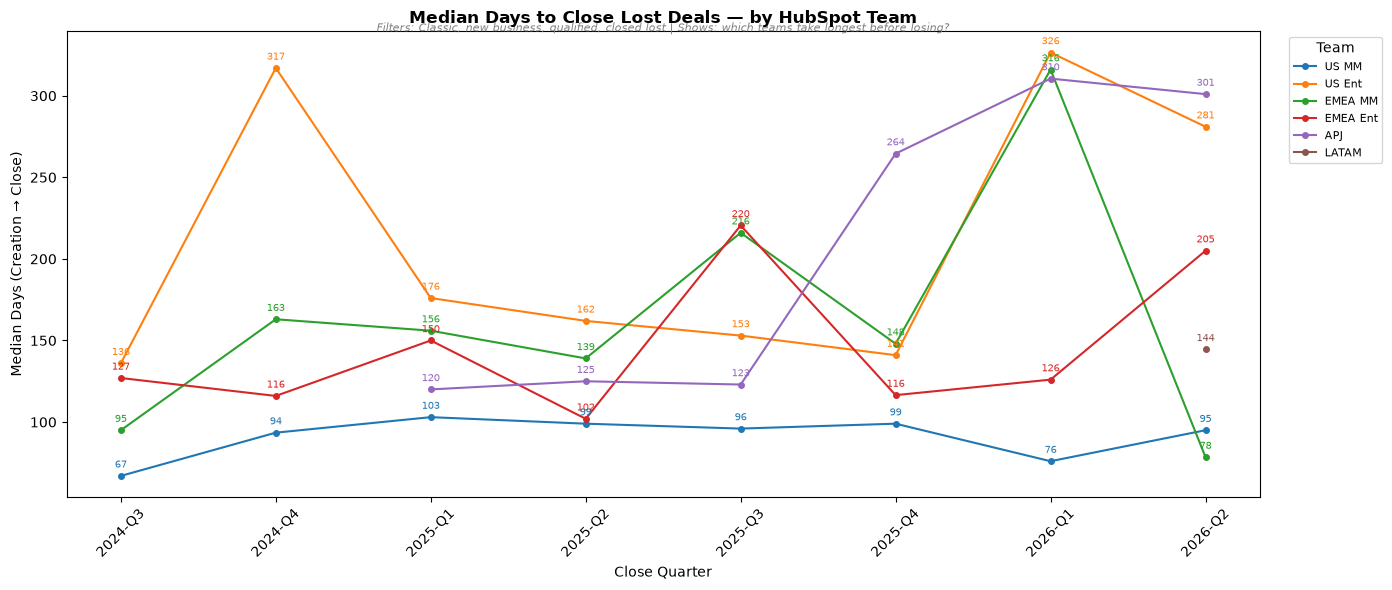

In [95]:
# Chart: Median Days to Close Lost Deals — by HubSpot Team
team_dwell_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    COALESCE(d.DEAL_TEAM_NAME, 'Unknown') AS team,
    MEDIAN(DATEDIFF('day', d.DEAL_CREATED_DATE, {DEAL_CLOSED_DATE_OVERRIDE})) AS median_dwell_days,
    COUNT(*) AS lost_deals,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
LEFT JOIN PORT_ANALYTICS_PROD.DWH.DIM_COMPANY c ON d.SK_COMPANY = c.SK_COMPANY
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND d.DEAL_TEAM_NAME IS NOT NULL
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
  AND COALESCE(c.COMPANY_NAME, '') NOT ILIKE '%test%'
  AND COALESCE(c.COMPANY_NAME, '') != 'Port'
GROUP BY 1, 2, 3
""")

df_td = team_dwell_data.copy()
df_td['MEDIAN_DWELL_DAYS'] = pd.to_numeric(df_td['MEDIAN_DWELL_DAYS'], errors='coerce')
df_td['LOST_DEALS'] = pd.to_numeric(df_td['LOST_DEALS'], errors='coerce').fillna(0)
df_td['LOST_ARR'] = pd.to_numeric(df_td['LOST_ARR'], errors='coerce').fillna(0)
quarter_order = df_td.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

# Keep top teams by total lost deals (drop the rest)
top_teams = df_td.groupby('TEAM')['LOST_DEALS'].sum().nlargest(6).index.tolist()
df_td = df_td[df_td['TEAM'].isin(top_teams)].copy()
team_colors = {team: plt.cm.tab10(i) for i, team in enumerate(top_teams)}

fig, ax = plt.subplots(figsize=(14, 6))
for team in top_teams:
    subset = df_td[df_td['TEAM'] == team].set_index('CLOSE_QUARTER').reindex(quarter_order)
    if subset['MEDIAN_DWELL_DAYS'].notna().any():
        line, = ax.plot(subset.index, subset['MEDIAN_DWELL_DAYS'], marker='o', markersize=4, label=team, color=team_colors[team])
        for x, y in zip(subset.index, subset['MEDIAN_DWELL_DAYS']):
            if pd.notna(y):
                ax.annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, ha='center', color=line.get_color())

ax.set_title('Median Days to Close Lost Deals — by HubSpot Team', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost | Shows: which teams take longest before losing?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('Median Days (Creation → Close)')
ax.set_xlabel('Close Quarter')
ax.legend(title='Team', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [96]:
# Table: Close Quarter x Team — deal count, total lost ARR, median days to close
tbl = team_dwell_data.copy()
tbl['MEDIAN_DWELL_DAYS'] = pd.to_numeric(tbl['MEDIAN_DWELL_DAYS'], errors='coerce')
tbl['LOST_DEALS'] = pd.to_numeric(tbl['LOST_DEALS'], errors='coerce').fillna(0).astype(int)
tbl['LOST_ARR'] = pd.to_numeric(tbl['LOST_ARR'], errors='coerce').fillna(0)

tbl = tbl[['CLOSE_QUARTER', 'TEAM', 'LOST_DEALS', 'LOST_ARR', 'MEDIAN_DWELL_DAYS']].rename(columns={
    'CLOSE_QUARTER': 'Close Quarter',
    'TEAM': 'Team',
    'LOST_DEALS': 'Lost Deals',
    'LOST_ARR': 'Lost ARR',
    'MEDIAN_DWELL_DAYS': 'Median Days to Close'
}).sort_values(['Close Quarter', 'Lost ARR'], ascending=[True, False]).reset_index(drop=True)

tbl_display = tbl.copy()
tbl_display['Lost ARR'] = tbl_display['Lost ARR'].map('${:,.0f}'.format)
tbl_display['Median Days to Close'] = tbl_display['Median Days to Close'].map('{:.0f}'.format)
tbl_display

,Close Quarter,Team,Lost Deals,Lost ARR,Median Days to Close
0,2024-Q3,US MM,20,"$1,066,600",67
1,2024-Q3,EMEA Ent,9,"$675,000",127
2,2024-Q3,EMEA MM,15,"$597,800",95
3,2024-Q3,US Ent,5,"$405,000",136
4,2024-Q4,EMEA Ent,10,"$814,500",116
5,2024-Q4,US Ent,10,"$778,675",317
6,2024-Q4,US MM,12,"$565,000",94
7,2024-Q4,EMEA MM,14,"$471,400",163
8,2025-Q1,US MM,34,"$2,040,240",103
9,2025-Q1,US Ent,19,"$1,468,000",176


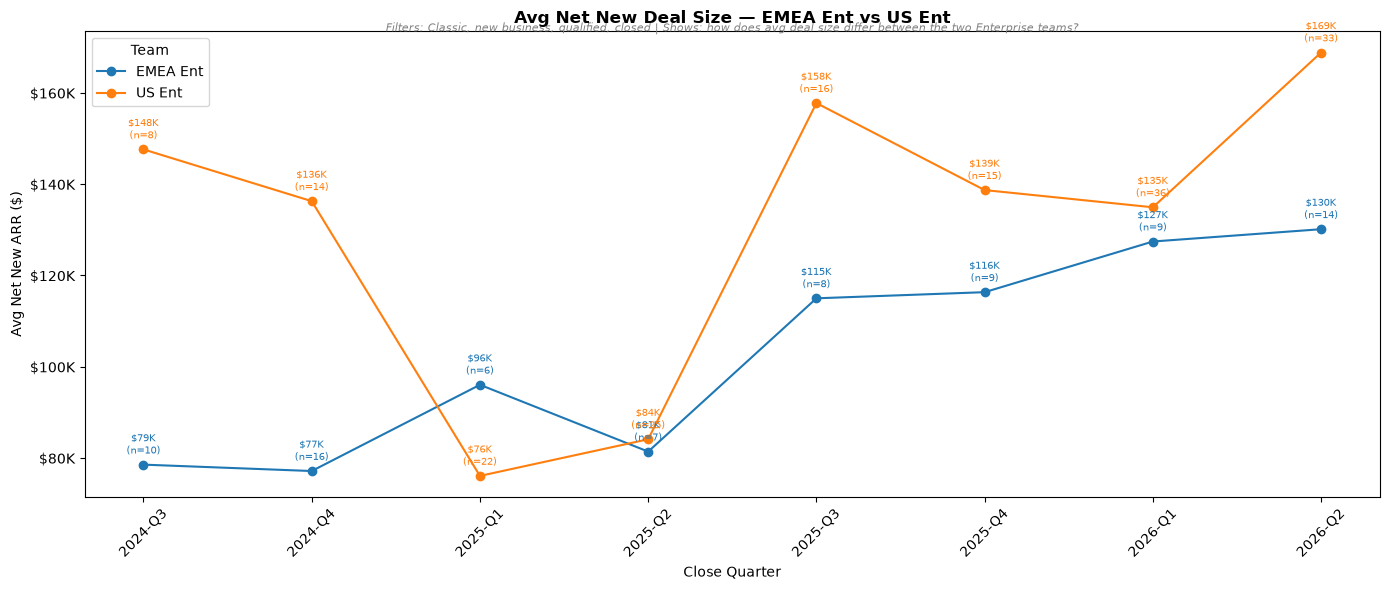

In [97]:
# Chart: Avg Net New Deal Size — EMEA Ent vs US Ent (qualified new business, by close quarter)
ent_size_data = run_query(f"""
SELECT
    CONCAT(YEAR({DEAL_CLOSED_DATE_OVERRIDE}), '-Q', QUARTER({DEAL_CLOSED_DATE_OVERRIDE})) AS close_quarter,
    DATE_TRUNC('quarter', {DEAL_CLOSED_DATE_OVERRIDE}) AS quarter_sort,
    d.DEAL_TEAM_NAME AS team,
    AVG(d.DEAL_NET_NEW_ARR) AS avg_deal_size,
    COUNT(*) AS deals
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.DEAL_TEAM_NAME IN ('EMEA Ent', 'US Ent')
  AND {DEAL_CLOSED_DATE_OVERRIDE} >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND {DEAL_CLOSED_DATE_OVERRIDE} <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, team
""")

df_es = ent_size_data.copy()
df_es['AVG_DEAL_SIZE'] = pd.to_numeric(df_es['AVG_DEAL_SIZE'], errors='coerce')
df_es['DEALS'] = pd.to_numeric(df_es['DEALS'], errors='coerce').fillna(0).astype(int)
quarter_order = df_es.sort_values('QUARTER_SORT')['CLOSE_QUARTER'].unique()

team_colors = {'EMEA Ent': 'tab:blue', 'US Ent': 'tab:orange'}
fig, ax = plt.subplots(figsize=(14, 6))
for team in ['EMEA Ent', 'US Ent']:
    subset = df_es[df_es['TEAM'] == team].set_index('CLOSE_QUARTER').reindex(quarter_order)
    if subset['AVG_DEAL_SIZE'].notna().any():
        line, = ax.plot(subset.index, subset['AVG_DEAL_SIZE'], marker='o', label=team, color=team_colors[team])
        for x, y, n in zip(subset.index, subset['AVG_DEAL_SIZE'], subset['DEALS']):
            if pd.notna(y):
                ax.annotate(f'${y/1000:.0f}K\n(n={n:.0f})', (x, y), textcoords="offset points", xytext=(0, 8), fontsize=7, ha='center', color=line.get_color())

ax.set_title('Avg Net New Deal Size — EMEA Ent vs US Ent', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed | Shows: how does avg deal size differ between the two Enterprise teams?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('Avg Net New ARR ($)')
ax.set_xlabel('Close Quarter')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax.legend(title='Team')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

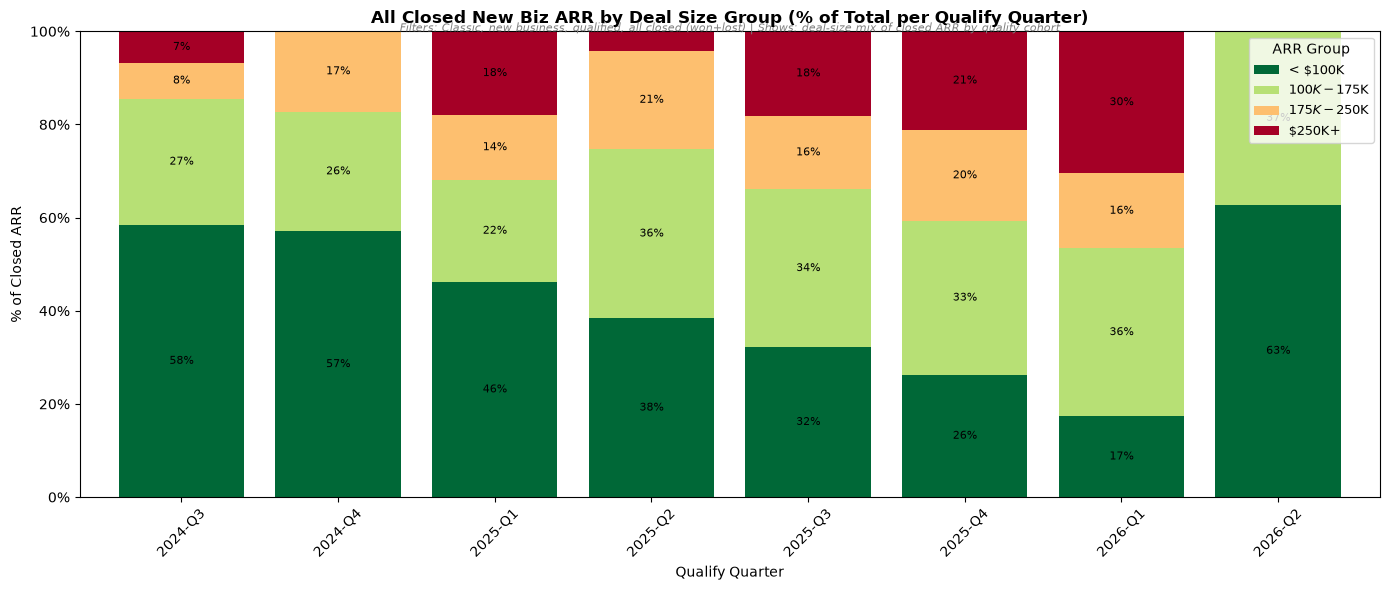

In [98]:
# Chart: All Closed New Biz ARR by Deal Size Group — by QUALIFY Quarter
arr_group_allclosed_data = run_query(f"""
SELECT
    CONCAT(YEAR(d.QUALIFIED_DATE), '-Q', QUARTER(d.QUALIFIED_DATE)) AS qualify_quarter,
    DATE_TRUNC('quarter', d.QUALIFIED_DATE) AS quarter_sort,
    CASE
        WHEN d.DEAL_NET_NEW_ARR < 100000 THEN '< $100K'
        WHEN d.DEAL_NET_NEW_ARR < 175000 THEN '$100K-$175K'
        WHEN d.DEAL_NET_NEW_ARR < 250000 THEN '$175K-$250K'
        ELSE '$250K+'
    END AS arr_group,
    SUM(d.DEAL_NET_NEW_ARR) AS deal_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.QUALIFIED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND d.QUALIFIED_DATE <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, arr_group
""")

df_ac = arr_group_allclosed_data.copy()
df_ac['DEAL_ARR'] = pd.to_numeric(df_ac['DEAL_ARR'], errors='coerce').fillna(0)
quarter_order = df_ac.sort_values('QUARTER_SORT')['QUALIFY_QUARTER'].unique()

pivot = df_ac.pivot_table(index='QUALIFY_QUARTER', columns='ARR_GROUP', values='DEAL_ARR', aggfunc='sum', fill_value=0)
col_order = ['< $100K', '$100K-$175K', '$175K-$250K', '$250K+']
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns]).reindex(quarter_order).fillna(0)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct.plot(kind='bar', stacked=True, ax=ax, width=0.8, colormap='RdYlGn_r')
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('All Closed New Biz ARR by Deal Size Group (% of Total per Qualify Quarter)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, all closed (won+lost) | Shows: deal-size mix of closed ARR by qualify cohort', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Closed ARR')
ax.set_xlabel('Qualify Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='ARR Group', loc='upper right', fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

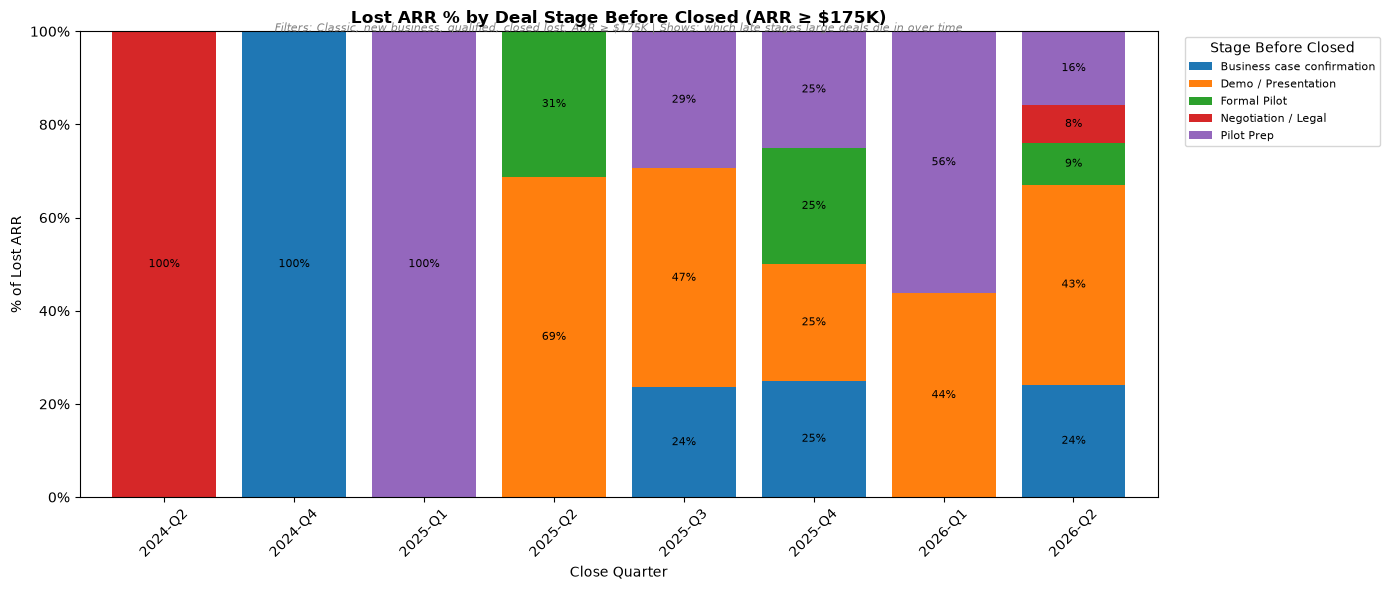

In [99]:
# Chart: Lost ARR % by Deal Stage Before Closed (ARR >= $175K) — 100% stacked area by close quarter
df_stg = hs_deals[hs_deals['Qualified Date'].notna()].copy()
df_stg['Amount'] = pd.to_numeric(df_stg['Amount'], errors='coerce').fillna(0)
df_stg = df_stg[df_stg['Amount'] >= 175000]
df_stg['Deal Stage Before Closed'] = df_stg['Deal Stage Before Closed'].fillna('Unknown')

quarter_order = df_stg.sort_values('Close Date')['close_quarter'].unique()
pivot_stg = df_stg.pivot_table(index='close_quarter', columns='Deal Stage Before Closed', values='Amount', aggfunc='sum', fill_value=0)
pivot_stg = pivot_stg.reindex(quarter_order).fillna(0)
pct_stg = pivot_stg.div(pivot_stg.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct_stg.plot(kind='bar', stacked=True, ax=ax, width=0.8)
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Lost ARR % by Deal Stage Before Closed (ARR ≥ $175K)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost, ARR ≥ $175K | Shows: which late stages large deals die in over time', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('Close Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Stage Before Closed', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [100]:
# Chart: Enterprise Lost ARR $ & Lost Deals # by Competitor (close quarter, stacked area)
# Segment logic per script: team overrides, else CSV Segment (hs_deals['segment'])
# Uses competitors_combined (structured 'Evaluated competitors' + extracted from Closed Lost Details)
comp_src = hs_deals[(hs_deals['segment'] == 'Enterprise') & hs_deals['Qualified Date'].notna()].copy()
comp_src['Amount'] = pd.to_numeric(comp_src['Amount'], errors='coerce').fillna(0)
comp_src = comp_src[comp_src['competitors_combined'].apply(len) > 0]

# Explode combined competitor list
exploded = comp_src.explode('competitors_combined').rename(columns={'competitors_combined': 'competitor'})
exploded['competitor'] = exploded['competitor'].str.strip()
exploded = exploded[exploded['competitor'].notna() & (exploded['competitor'] != '')]

# Filter out competitors mentioned only once (across all deals)
comp_counts = exploded['competitor'].value_counts()
keep = comp_counts[comp_counts > 1].index.tolist()
exploded = exploded[exploded['competitor'].isin(keep)]

# Split evenly: a deal citing N competitors contributes 1/N (deal) and Amount/N (ARR) to each
deal_comp_count = exploded.groupby('Record ID')['competitor'].transform('count')
exploded['deal_weight'] = 1.0 / deal_comp_count
exploded['arr_weighted'] = exploded['Amount'] * exploded['deal_weight']

quarter_order = exploded.sort_values('Close Date')['close_quarter'].unique()

# --- Deal count: assign each deal to ONE primary competitor by priority ---
# Priority: Backstage > Cortex > Harness > Compass > else (first remaining, alphabetical)
PRIORITY = ['Backstage', 'Cortex', 'Harness', 'Compass']
def primary_competitor(comps):
    lower = {c.lower(): c for c in comps}
    for p in PRIORITY:
        if p.lower() in lower:
            return lower[p.lower()]
    return sorted(comps)[0]

deal_primary = exploded.groupby('Record ID').agg(
    close_quarter=('close_quarter', 'first'),
    competitors=('competitor', lambda s: set(s))
).reset_index()
deal_primary['primary'] = deal_primary['competitors'].apply(primary_competitor)

# Aggregate: fractional lost ARR $ (split evenly) and whole-deal count (primary competitor)
arr_pivot = exploded.pivot_table(index='close_quarter', columns='competitor', values='arr_weighted', aggfunc='sum', fill_value=0).reindex(quarter_order).fillna(0)
deals_pivot = deal_primary.pivot_table(index='close_quarter', columns='primary', values='Record ID', aggfunc='count', fill_value=0).reindex(quarter_order).fillna(0)

# Consistent competitor color order (by total ARR)
comp_order = arr_pivot.sum().sort_values(ascending=False).index.tolist()
arr_pivot = arr_pivot[comp_order]
deals_pivot = deals_pivot.reindex(columns=comp_order, fill_value=0)
comp_colors = {c: plt.cm.tab20(i % 20) for i, c in enumerate(comp_order)}

def label_stack(ax, pivot, fmt, min_frac=0.08):
    """Label big bands at their center; skip labels that would overlap vertically."""
    x = np.arange(len(pivot.index))
    ymax = pivot.sum(axis=1).max()
    min_gap = ymax * 0.05  # min vertical spacing between labels
    for xi, q in enumerate(pivot.index):
        cum = 0.0
        placed = []  # y-positions already labeled at this x
        col_total = pivot.loc[q].sum()
        for c in comp_order:
            v = pivot.loc[q, c]
            if v > 0:
                center = cum + v / 2
                # "big" = band is at least min_frac of the quarter's total
                if col_total > 0 and v >= min_frac * col_total:
                    if all(abs(center - p) >= min_gap for p in placed):
                        ax.text(xi, center, fmt(v), ha='center', va='center', fontsize=7, fontweight='bold')
                        placed.append(center)
                cum += v

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# --- Top: Lost ARR $ ---
ax1 = axes[0]
ax1.stackplot(np.arange(len(arr_pivot.index)), [arr_pivot[c].values for c in comp_order], labels=comp_order,
              colors=[comp_colors[c] for c in comp_order], alpha=0.85)
label_stack(ax1, arr_pivot, lambda v: f'${v/1000:.0f}K')
ax1.set_title('Enterprise Only — Lost ARR $ by Competitor (ARR split evenly across cited competitors)', fontsize=12, fontweight='bold')
ax1.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost, Enterprise, competitor mentioned >1x, ARR split evenly across cited competitors | Shows: which competitors drive lost ARR', transform=ax1.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax1.set_ylabel('Lost ARR ($)')
ax1.set_xlabel('Close Quarter')
ax1.set_xticks(np.arange(len(arr_pivot.index)))
ax1.set_xticklabels(arr_pivot.index, rotation=45)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax1.legend(title='Competitor', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# --- Bottom: Lost Deals # ---
ax2 = axes[1]
ax2.stackplot(np.arange(len(deals_pivot.index)), [deals_pivot[c].values for c in comp_order], labels=comp_order,
              colors=[comp_colors[c] for c in comp_order], alpha=0.85)
label_stack(ax2, deals_pivot, lambda v: f'{v:.0f}')
ax2.set_title('Enterprise Only — Lost Deals # by Primary Competitor (priority: Backstage > Cortex > Harness > Compass > other)', fontsize=12, fontweight='bold')
ax2.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost, Enterprise, competitor mentioned >1x, each deal assigned to one primary competitor | Shows: which competitors appear in the most lost deals', transform=ax2.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax2.set_ylabel('Lost Deals (#)')
ax2.set_xlabel('Close Quarter')
ax2.set_xticks(np.arange(len(deals_pivot.index)))
ax2.set_xticklabels(deals_pivot.index, rotation=45)
ax2.legend(title='Competitor', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

KeyError: 'competitors_combined'

In [ ]:
# Extract competitors from free-text "Closed Lost Details" using the known competitor list
import re

# Canonical competitor list from the structured "Evaluated competitors" field (drop non-competitors)
KNOWN_COMPETITORS = [c for c in sorted(set(
    x.strip() for v in hs_deals['Evaluated competitors'].dropna()
    for x in str(v).split(';') if x.strip() and x.strip().lower() not in ('none', 'unknown')
))]

# Precompile a word-boundary, case-insensitive pattern per competitor
comp_patterns = {c: re.compile(r'\b' + re.escape(c) + r'\b', re.IGNORECASE) for c in KNOWN_COMPETITORS}

def extract_competitors_from_text(text):
    if pd.isna(text) or not str(text).strip():
        return []
    found = [c for c, pat in comp_patterns.items() if pat.search(str(text))]
    return found

hs_deals['competitors_from_details'] = hs_deals['Closed Lost Details'].apply(extract_competitors_from_text)

# Structured competitors as a set for comparison
def parse_structured(v):
    if pd.isna(v):
        return set()
    return {x.strip() for x in str(v).split(';') if x.strip() and x.strip().lower() not in ('none', 'unknown')}

hs_deals['competitors_structured'] = hs_deals['Evaluated competitors'].apply(parse_structured)
hs_deals['competitors_combined'] = hs_deals.apply(
    lambda r: sorted(r['competitors_structured'] | set(r['competitors_from_details'])), axis=1)

# Coverage summary
n_total = len(hs_deals)
n_structured = (hs_deals['competitors_structured'].apply(len) > 0).sum()
n_text = (hs_deals['competitors_from_details'].apply(len) > 0).sum()
n_combined = (hs_deals['competitors_combined'].apply(len) > 0).sum()
n_text_only = ((hs_deals['competitors_from_details'].apply(len) > 0) & (hs_deals['competitors_structured'].apply(len) == 0)).sum()

print(f"Total lost deals:                        {n_total}")
print(f"With structured 'Evaluated competitors': {n_structured} ({100*n_structured/n_total:.0f}%)")
print(f"With competitors found in details text:  {n_text} ({100*n_text/n_total:.0f}%)")
print(f"Combined coverage:                       {n_combined} ({100*n_combined/n_total:.0f}%)")
print(f"Deals gained ONLY from text extraction:  {n_text_only}")

# Show examples where text extraction added net-new competitor info
gained = hs_deals[(hs_deals['competitors_from_details'].apply(len) > 0) & (hs_deals['competitors_structured'].apply(len) == 0)]
gained[['Record ID', 'Deal Name', 'competitors_from_details', 'Closed Lost Details']].head(15)

In [ ]:
# Chart: Closed Lost ARR by Deal Size Group — by QUALIFY Quarter
arr_group_qual_data = run_query(f"""
SELECT
    CONCAT(YEAR(d.QUALIFIED_DATE), '-Q', QUARTER(d.QUALIFIED_DATE)) AS qualify_quarter,
    DATE_TRUNC('quarter', d.QUALIFIED_DATE) AS quarter_sort,
    CASE
        WHEN d.DEAL_NET_NEW_ARR < 100000 THEN '< $100K'
        WHEN d.DEAL_NET_NEW_ARR < 175000 THEN '$100K-$175K'
        WHEN d.DEAL_NET_NEW_ARR < 250000 THEN '$175K-$250K'
        ELSE '$250K+'
    END AS arr_group,
    SUM(d.DEAL_NET_NEW_ARR) AS lost_arr
FROM PORT_ANALYTICS_PROD.DWH.FACT_DEALS d
WHERE d.QUALIFIED_DATE IS NOT NULL
  AND d.PIPELINE = 'Classic'
  AND d.DEAL_TYPE = 'newbusiness'
  AND d.ARCHIVED = FALSE
  AND d._DELETED_TIMESTAMP IS NULL
  AND d.IS_CLOSED = TRUE
  AND d.IS_WON = FALSE
  AND d.QUALIFIED_DATE >= DATEADD(quarter, -{N_QUARTERS}, DATE_TRUNC('quarter', CURRENT_DATE()))
  AND d.QUALIFIED_DATE <= '2026-06-30'
GROUP BY 1, 2, 3
ORDER BY quarter_sort, arr_group
""")

df_agq = arr_group_qual_data.copy()
df_agq['LOST_ARR'] = pd.to_numeric(df_agq['LOST_ARR'], errors='coerce').fillna(0)
quarter_order = df_agq.sort_values('QUARTER_SORT')['QUALIFY_QUARTER'].unique()

pivot = df_agq.pivot_table(index='QUALIFY_QUARTER', columns='ARR_GROUP', values='LOST_ARR', aggfunc='sum', fill_value=0)
col_order = ['< $100K', '$100K-$175K', '$175K-$250K', '$250K+']
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns]).reindex(quarter_order).fillna(0)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pct.plot(kind='bar', stacked=True, ax=ax, width=0.8, colormap='RdYlGn_r')
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Closed Lost ARR by Deal Size Group (% of Total per Qualify Quarter)', fontsize=12, fontweight='bold')
ax.text(0.5, 1.0, 'Filters: Classic, new business, qualified, closed lost | Shows: which deal-size bands dominate losses by qualify cohort?', transform=ax.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax.set_ylabel('% of Lost ARR')
ax.set_xlabel('Qualify Quarter')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='ARR Group', loc='upper right', fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 8: Lost Deal Profile — Owner Change × Time Since Qualification × Stage Before Lost

**Hypothesis:** Deals that changed owner, lingered post-qualification, or died early in the pipeline have distinct profiles.

Three sub-charts showing % of all lost deals (count) by:
1. Owner changed (yes/no)
2. Time from qualification to close (bucketed)
3. Last stage before closed-lost

Deals > $100K: 90 deals, $17.8M ARR across 10 quarters


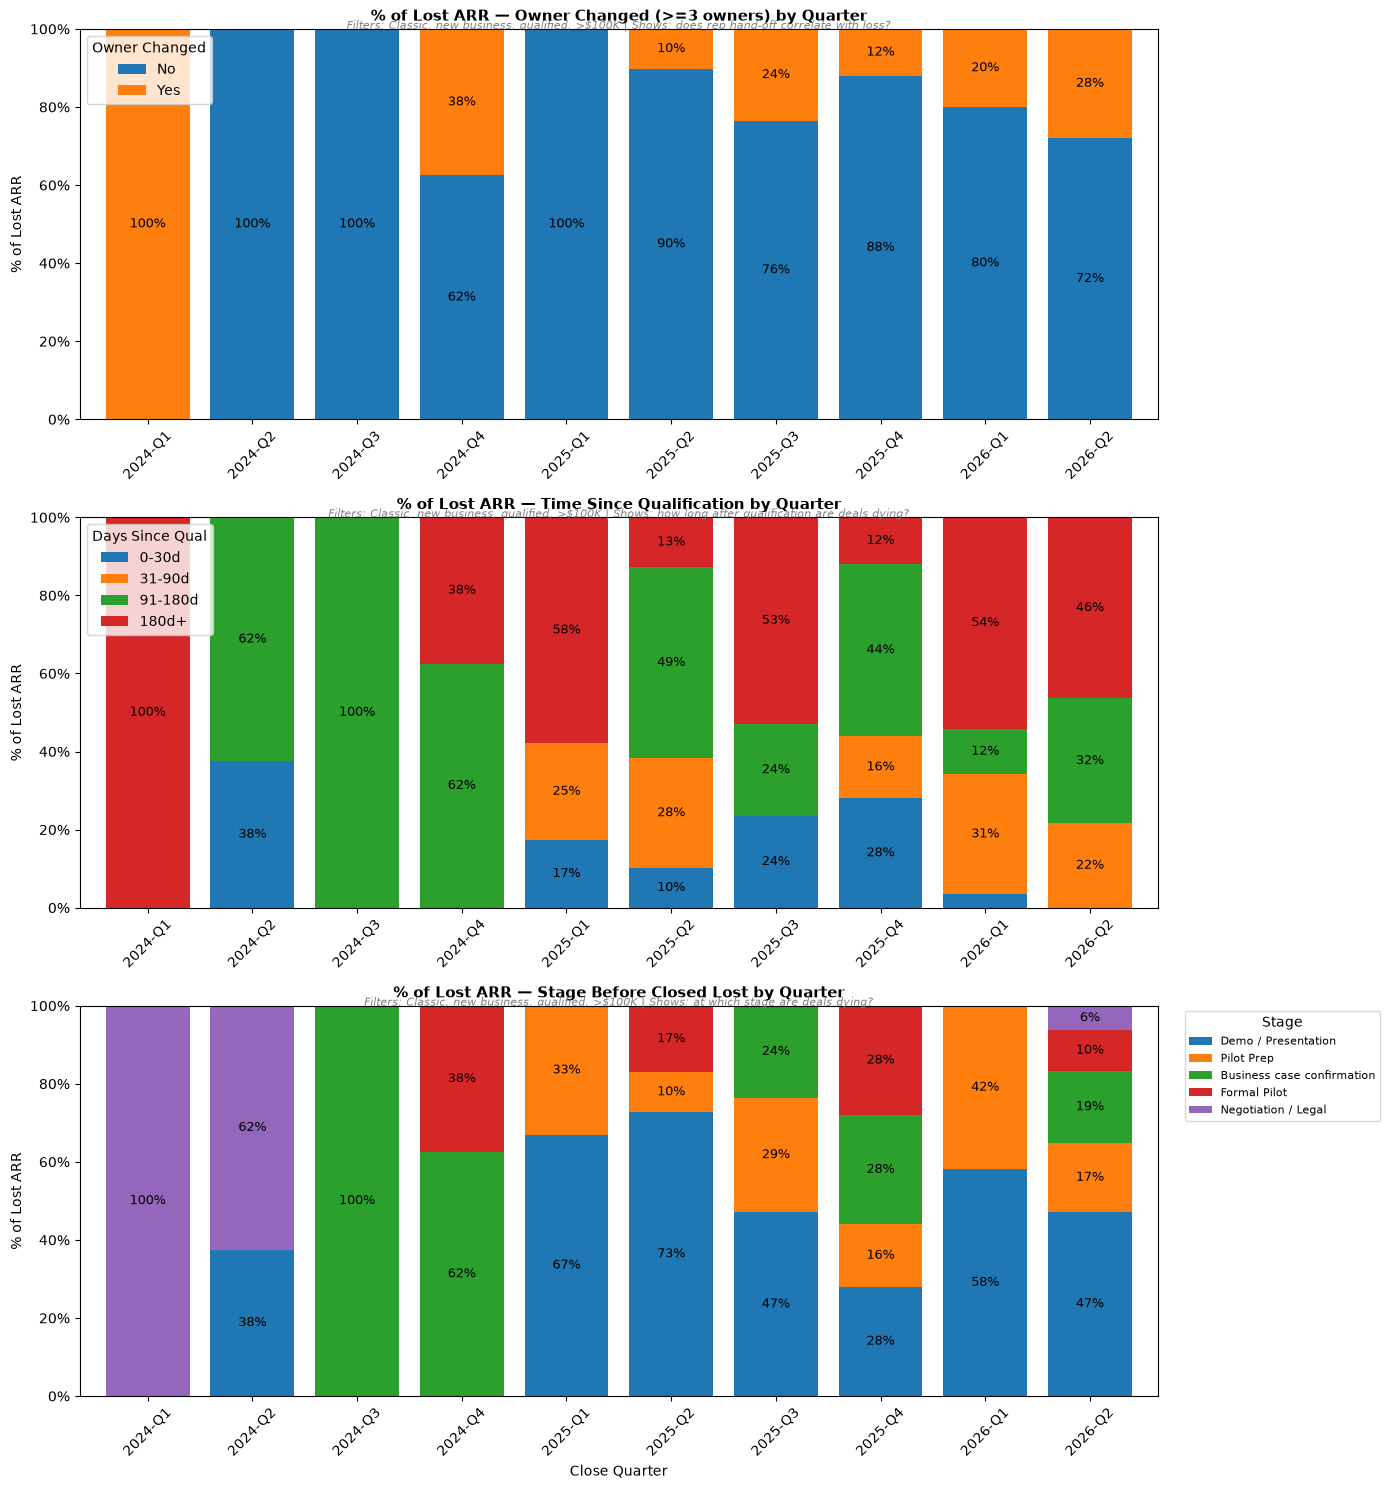

In [108]:
# Chart 8: Lost deal profile — % of lost ARR by quarter (stacked bars)
# Filters: Classic, new business, qualified, closed lost, Amount > $100K

# Build the analysis DataFrame from hs_deals (qualified deals only, >$100K)
profile_df = hs_deals[hs_deals['Qualified Date'].notna()].copy()
profile_df['Amount'] = pd.to_numeric(profile_df['Amount'], errors='coerce').fillna(0)
profile_df = profile_df[profile_df['Amount'] > 100000].reset_index(drop=True)

# 1) Owner changed — compute distinct owners from owner_history
distinct_owners = owner_history.groupby('deal_id')['value'].nunique().reset_index()
distinct_owners.columns = ['Record ID', 'distinct_owners']
profile_df = profile_df.merge(distinct_owners, on='Record ID', how='left')
profile_df['distinct_owners'] = profile_df['distinct_owners'].fillna(1)
profile_df['owner_changed'] = profile_df['distinct_owners'].apply(lambda x: 'Yes' if x >= 3 else 'No')

# 2) Time since qualification (bucketed)
profile_df['days_since_qual'] = (profile_df['Close Date'] - profile_df['Qualified Date']).dt.days

def qual_bucket(days):
    if pd.isna(days) or days < 0: return 'Unknown'
    if days <= 30: return '0-30d'
    if days <= 90: return '31-90d'
    if days <= 180: return '91-180d'
    return '180d+'

profile_df['qual_bucket'] = profile_df['days_since_qual'].apply(qual_bucket)

# 3) Stage before lost (from HubSpot CSV column)
profile_df['stage_before_lost'] = profile_df['Deal Stage Before Closed'].fillna('Unknown')

# Quarter ordering
quarter_order = sorted(profile_df['close_quarter'].unique())
print(f'Deals > $100K: {len(profile_df)} deals, ${profile_df["Amount"].sum()/1e6:.1f}M ARR across {len(quarter_order)} quarters')

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Panel 1: % of lost ARR by owner changed, per quarter
ax1 = axes[0]
pivot1 = profile_df.pivot_table(index='close_quarter', columns='owner_changed', values='Amount', aggfunc='sum', fill_value=0)
pivot1 = pivot1.reindex(quarter_order).fillna(0)
pct1 = pivot1.div(pivot1.sum(axis=1), axis=0) * 100
pct1.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color={'No': 'tab:blue', 'Yes': 'tab:orange'})
for container in ax1.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax1.bar_label(container, labels=labels, label_type='center', fontsize=9)
ax1.set_title('% of Lost ARR — Owner Changed (>=3 owners) by Quarter', fontsize=11, fontweight='bold')
ax1.text(0.5, 1.0, 'Filters: Classic, new business, qualified, >$100K | Shows: does rep hand-off correlate with loss?', transform=ax1.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax1.set_ylabel('% of Lost ARR')
ax1.set_xlabel('')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(title='Owner Changed')
ax1.tick_params(axis='x', rotation=45)

# Panel 2: % of lost ARR by time-since-qualification bucket, per quarter
ax2 = axes[1]
bucket_order = ['0-30d', '31-90d', '91-180d', '180d+']
pivot2 = profile_df.pivot_table(index='close_quarter', columns='qual_bucket', values='Amount', aggfunc='sum', fill_value=0)
pivot2 = pivot2.reindex(quarter_order).fillna(0)
pivot2 = pivot2[[c for c in bucket_order if c in pivot2.columns]]
pct2 = pivot2.div(pivot2.sum(axis=1), axis=0) * 100
pct2.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
for container in ax2.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=9)
ax2.set_title('% of Lost ARR — Time Since Qualification by Quarter', fontsize=11, fontweight='bold')
ax2.text(0.5, 1.0, 'Filters: Classic, new business, qualified, >$100K | Shows: how long after qualification are deals dying?', transform=ax2.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax2.set_ylabel('% of Lost ARR')
ax2.set_xlabel('')
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(title='Days Since Qual')
ax2.tick_params(axis='x', rotation=45)

# Panel 3: % of lost ARR by stage before lost, per quarter (top 5 + Other)
ax3 = axes[2]
top_stages = profile_df.groupby('stage_before_lost')['Amount'].sum().sort_values(ascending=False).head(5).index.tolist()
profile_df['stage_top'] = profile_df['stage_before_lost'].apply(lambda x: x if x in top_stages else 'Other')
pivot3 = profile_df.pivot_table(index='close_quarter', columns='stage_top', values='Amount', aggfunc='sum', fill_value=0)
pivot3 = pivot3.reindex(quarter_order).fillna(0)
col_order = [c for c in top_stages if c in pivot3.columns] + (['Other'] if 'Other' in pivot3.columns else [])
pivot3 = pivot3[col_order]
pct3 = pivot3.div(pivot3.sum(axis=1), axis=0) * 100
pct3.plot(kind='bar', stacked=True, ax=ax3, width=0.8)
for container in ax3.containers:
    labels = [f'{v:.0f}%' if v > 5 else '' for v in container.datavalues]
    ax3.bar_label(container, labels=labels, label_type='center', fontsize=9)
ax3.set_title('% of Lost ARR — Stage Before Closed Lost by Quarter', fontsize=11, fontweight='bold')
ax3.text(0.5, 1.0, 'Filters: Classic, new business, qualified, >$100K | Shows: at which stage are deals dying?', transform=ax3.transAxes, fontsize=8, ha='center', color='gray', style='italic')
ax3.set_ylabel('% of Lost ARR')
ax3.set_xlabel('Close Quarter')
ax3.set_ylim(0, 100)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend(title='Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()